In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
redwankarimsony_heart_disease_data_path = kagglehub.dataset_download('redwankarimsony/heart-disease-data')

print('Data source import complete.')

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Data source import complete.


# Data Preparation


## Importing Packages & Dataset


In [ ]:
# Importing packages we will be using
import pandas as pd
import numpy as np
import missingno as msn
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Loading the dataset and taking a look at it
df = pd.read_csv("/kaggle/input/heart-disease-data/heart_disease_uci.csv")
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
# Having some insights about our datase
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## Dividing Features into Categorical & Quantitative Features


In [ ]:
# Quantitative (Numerical) Features
quantitative_features = [
    "age",        # Age in years
    "trestbps",   # Resting blood pressure (mm Hg)
    "chol",       # Serum cholesterol (mg/dl)
    "thalach",    # Maximum heart rate achieved
    "oldpeak",    # ST depression induced by exercise
    "ca"          # Number of major vessels (0–3)
]

# Categorical Features
categorical_features = [
    "sex",        # Male / Female
    "cp",         # Chest pain type
    "fbs",        # Fasting blood sugar > 120 mg/dl
    "restecg",    # Resting ECG results
    "exang",      # Exercise-induced angina
    "slope",      # Slope of peak exercise ST segment
    "thal"        # Thalassemia
]

# Target Variable (Binary Classification)
target_variable = "num"

# Print feature groups
print("\nQuantitative Features:", quantitative_features)
print("Categorical Features:", categorical_features)
print("Target Variable:", target_variable)


Quantitative Features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Target Variable: num


## Data Cleaning


<Axes: >

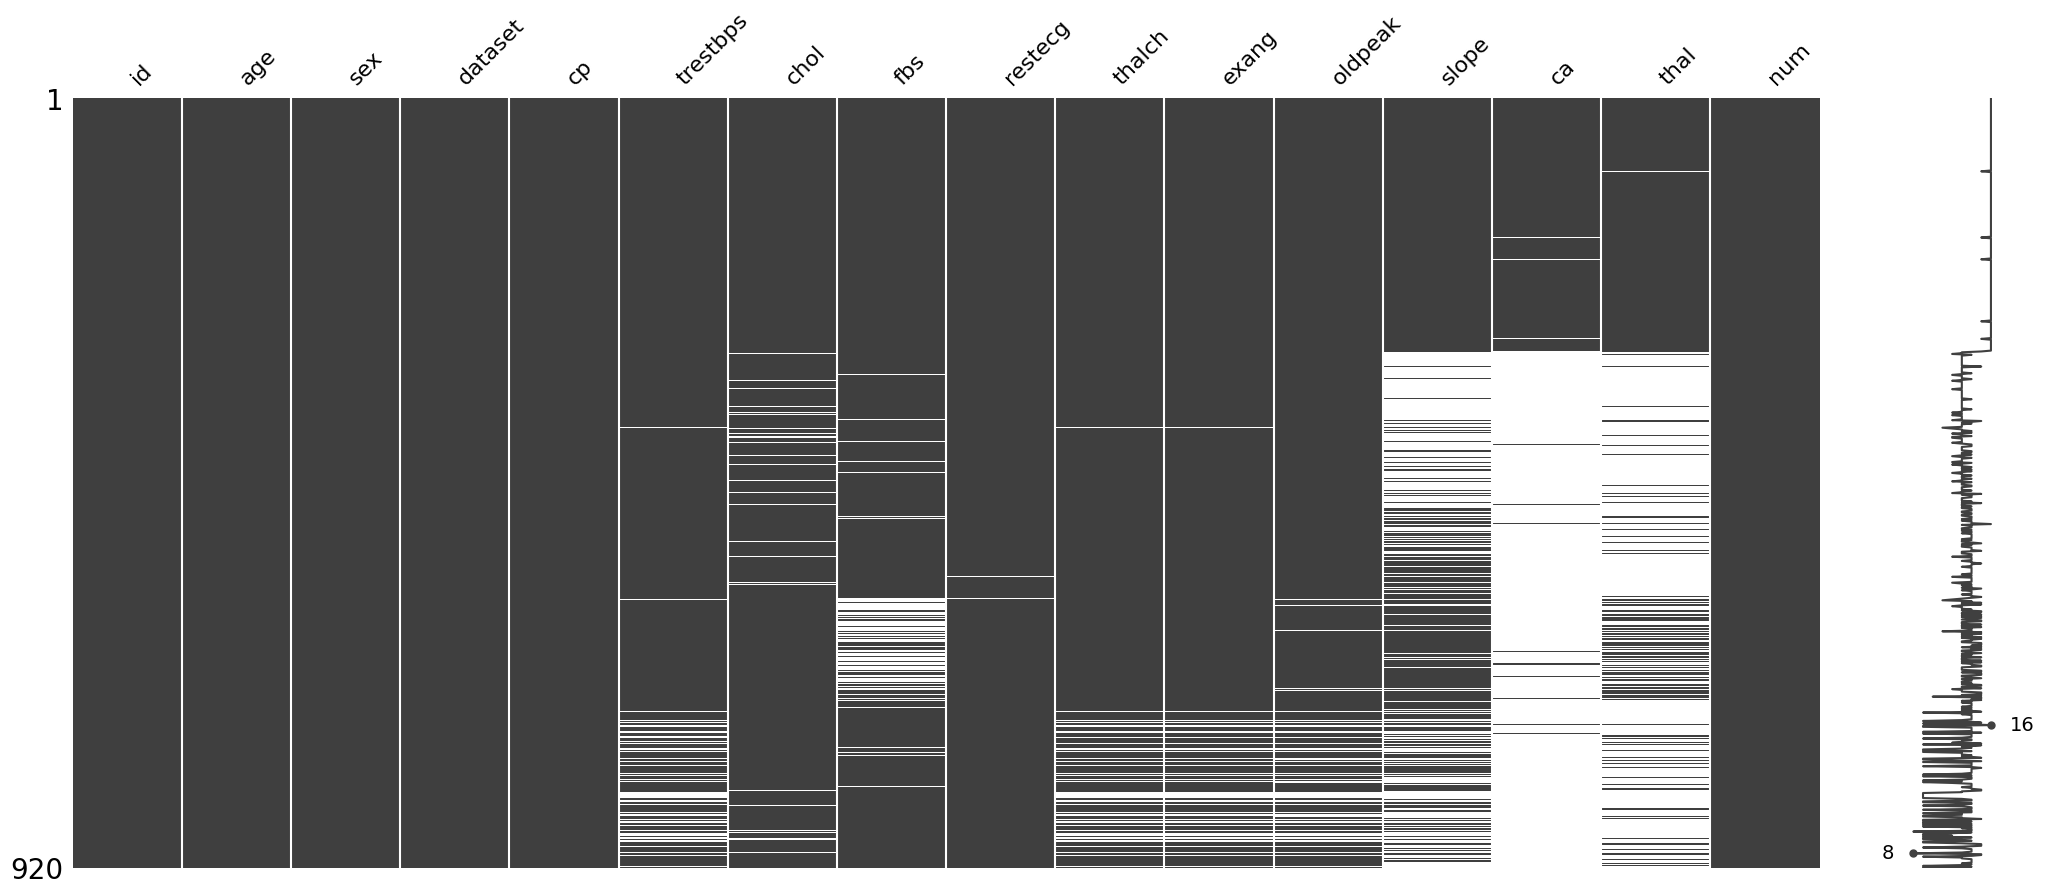

In [ ]:
# Searching whether there is any null values or not
msn.matrix(df)

In [ ]:
# Checking whether we have any quantitative zero values or not
for feature in df.columns:
    print(f"{feature} : {df[feature].eq(0).any()}")

id : False
age : False
sex : False
dataset : False
cp : False
trestbps : True
chol : True
fbs : True
restecg : False
thalch : False
exang : True
oldpeak : True
slope : False
ca : True
thal : False
num : True


In [ ]:
# Checking whether we have any duplicate rows or not
df.duplicated().any()

np.False_

### Feature Elimination Based on Missing Data Analysis

An inspection of the dataset using a missingness matrix reveals that the variables
**`ca`**, **`slope`**, and **`thal`** contain a substantial proportion of missing values
compared to other features.

- **`ca` (number of major vessels)** contains valid entries for only a small subset
  of patients, indicating that this measurement was not consistently recorded.
- **`slope` (slope of the peak exercise ST segment)** exhibits extensive missingness,
  which would require aggressive imputation and could introduce bias.
- **`thal` (thalassemia status)** has more than half of its values missing, making
  statistical imputation unreliable and potentially misleading.

Including variables with high levels of missing data can:
- Distort the underlying data distribution after imputation
- Increase noise and reduce model generalization
- Introduce bias, especially in medical decision-making tasks

Therefore, to preserve data integrity, reduce preprocessing bias, and ensure
robust statistical analysis, the features **`ca`**, **`slope`**, and **`thal`**
are removed from further analysis.


In [ ]:
# Drop Features with Excessive Missing Values
# Columns identified for removal due to high missingness and Unsuitability
columns_to_drop = ["ca", "slope", "thal","id","dataset"]

# Drop the columns from the dataset
df.drop(columns=columns_to_drop, inplace=True)

# Verify the remaining columns
print("Remaining columns:")
print(df.columns)


Remaining columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'num'],
      dtype='object')


In [ ]:
quantitative_features = [
    "age",        # Age of the patient (years)
    "trestbps",   # Resting blood pressure (mm Hg)
    "chol",       # Serum cholesterol (mg/dl)
    "thalch",     # Maximum heart rate achieved
    "oldpeak"     # ST depression induced by exercise
]
categorical_features = [
    "sex",        # Male / Female
    "cp",         # Chest pain type
    "fbs",        # Fasting blood sugar > 120 mg/dl
    "restecg",    # Resting ECG results
    "exang",      # Exercise-induced angina
    "dataset"     # Origin of the data
]
target_variable = "num"

print("\nQuantitative Features:", quantitative_features)
print("Categorical Features:", categorical_features)
print("Target Variable:", target_variable)




Quantitative Features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical Features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'dataset']
Target Variable: num


### Handling Remaining Missing Values

After removing features with excessive missing data (`ca`, `slope`, and `thal`),
the remaining variables still contain a limited number of missing values.
These missing entries are handled using statistically appropriate imputation
strategies based on the type of each variable.

- **Quantitative (numerical) features** are imputed using the **median** value.
  The median is robust to skewed distributions and outliers, which are common
  in biomedical measurements such as cholesterol and blood pressure.
- **Categorical features** are imputed using the **mode** (most frequent value),
  preserving the most representative category without introducing artificial
  numerical relationships.

This approach ensures:
- Preservation of dataset size
- Minimal distortion of data distributions
- Statistically sound preprocessing suitable for biomedical analysis

No missing values remain after this step, allowing safe progression to
subsequent modeling stages.


In [ ]:
 # Handle numerical features
for feature in quantitative_features:
    if feature in df.columns:
        if df[feature].isnull().sum() > 0:
            median_value = df[feature].median()
            df[feature] = df[feature].fillna(median_value)

# Handle categorical features
for feature in categorical_features:
    if feature in df.columns:
        if df[feature].isnull().sum() > 0:
            mode_value = df[feature].mode()[0]
            df[feature] = df[feature].fillna(mode_value)

/tmp/ipython-input-3886085592.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[feature] = df[feature].fillna(mode_value)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   920 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.6+ KB


<Axes: >

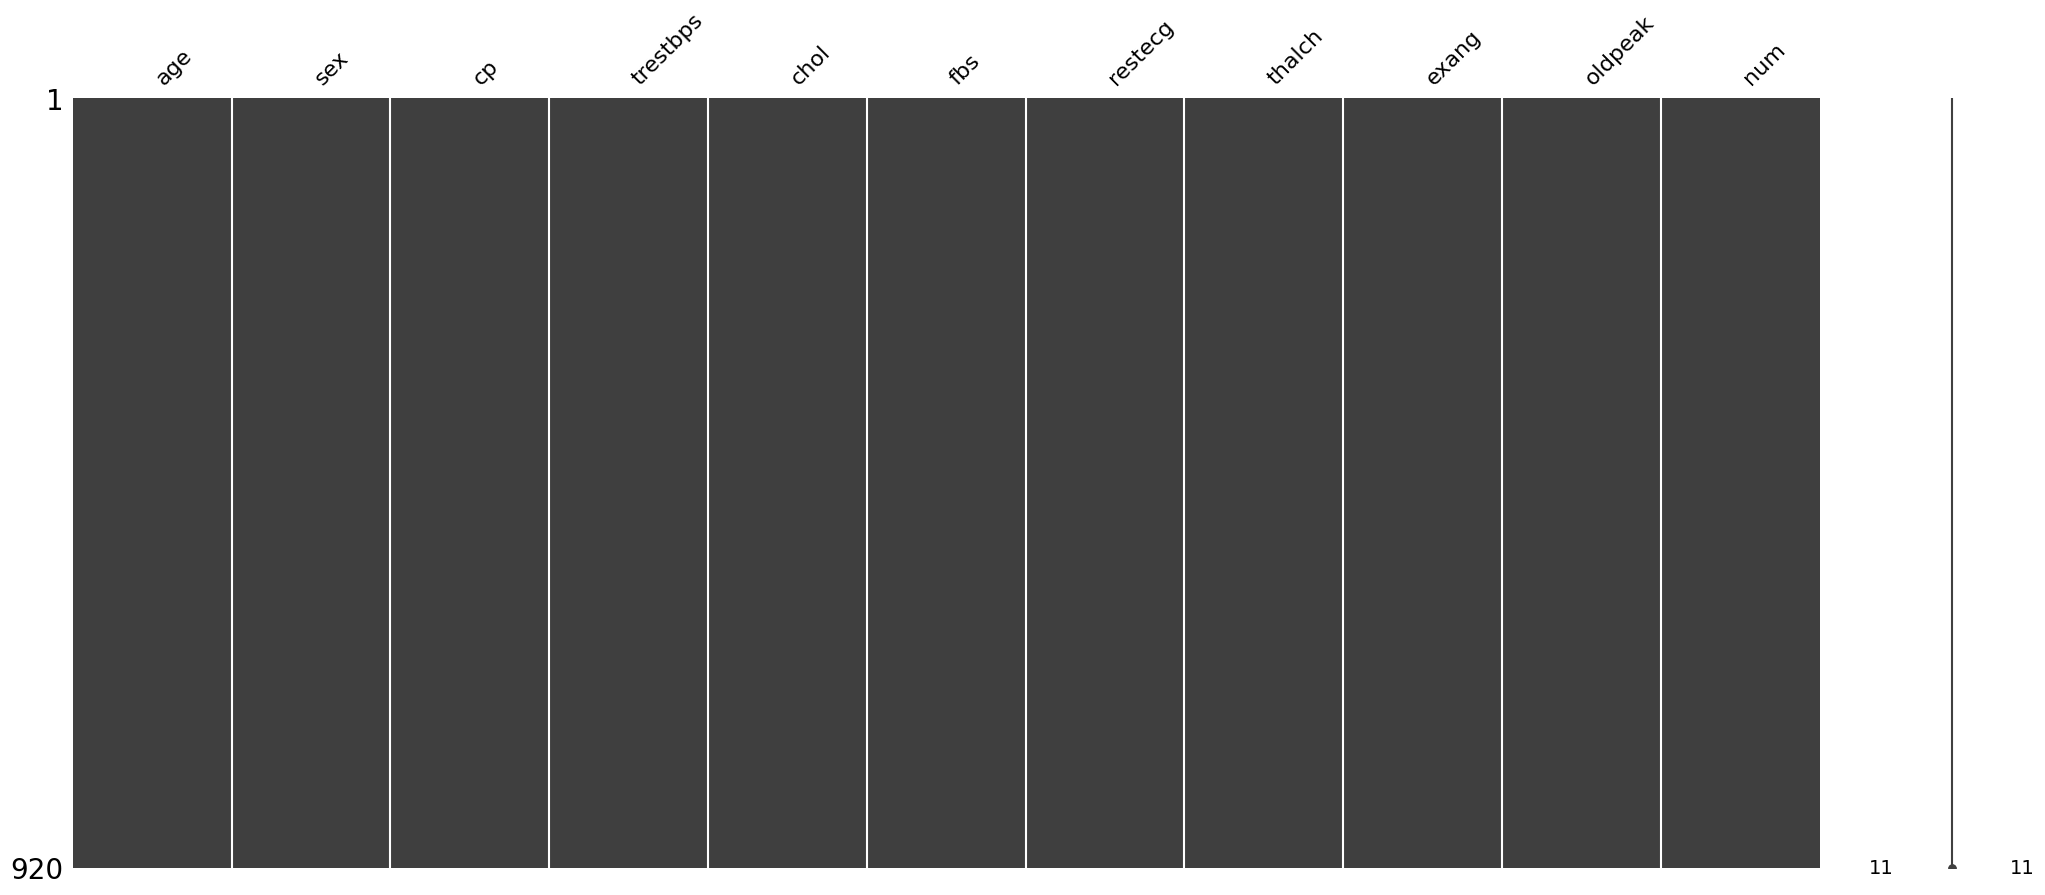

In [ ]:
msn.matrix(df)

# Dealing with Outliers


In [ ]:
# Importing packages we will be using
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox


## Visualizing Outliers for all Quantitative Features


Text(0.5, 1.0, 'Box Plots for Quantitative Features')

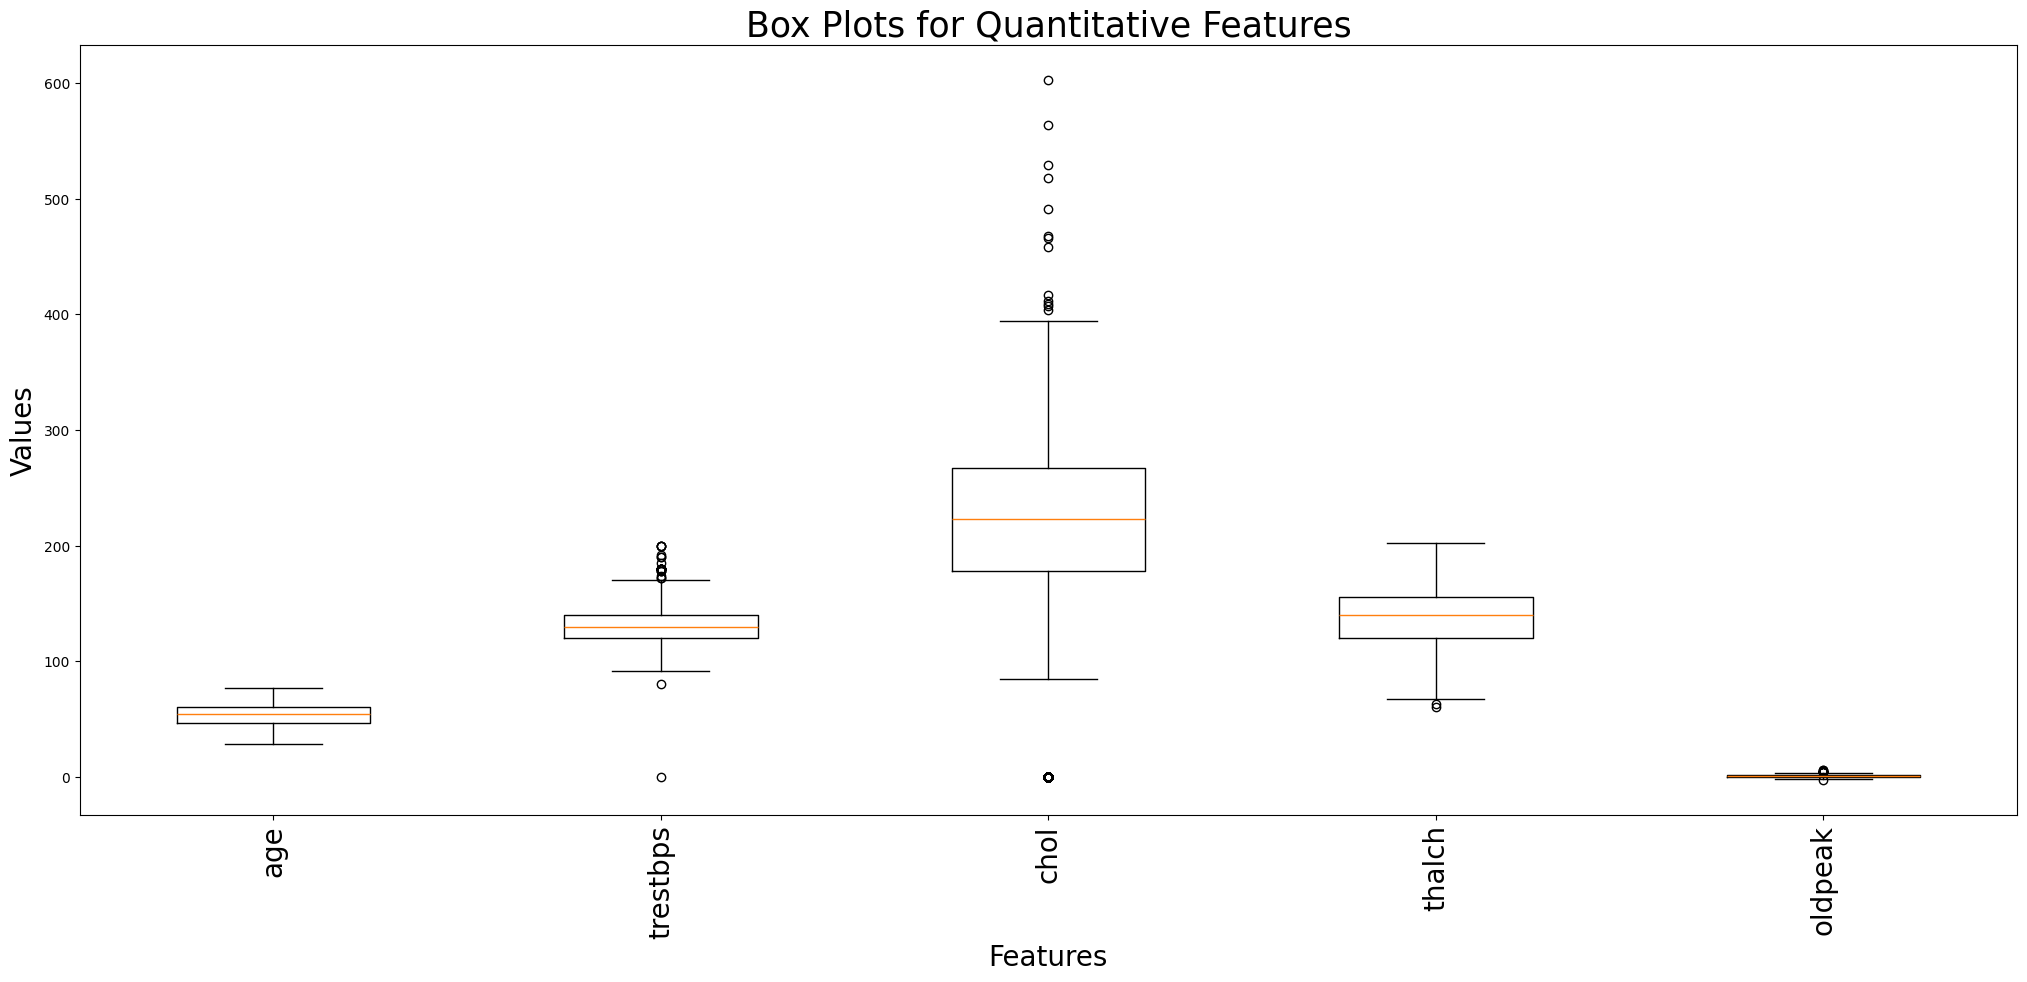

In [ ]:
# Plotting box plots for all features
fig = plt.figure(figsize=(25, 10))
ax = fig.add_subplot(1, 1, 1)
ax.boxplot(df[quantitative_features])
ax.set_xticklabels(quantitative_features, rotation='vertical', fontsize="20")
ax.set_xlabel("Features", fontsize="20")
ax.set_ylabel("Values", fontsize="20")
ax.set_title("Box Plots for Quantitative Features",  fontsize="25")


## Visualizing Outliers for each Feature using Box Plots


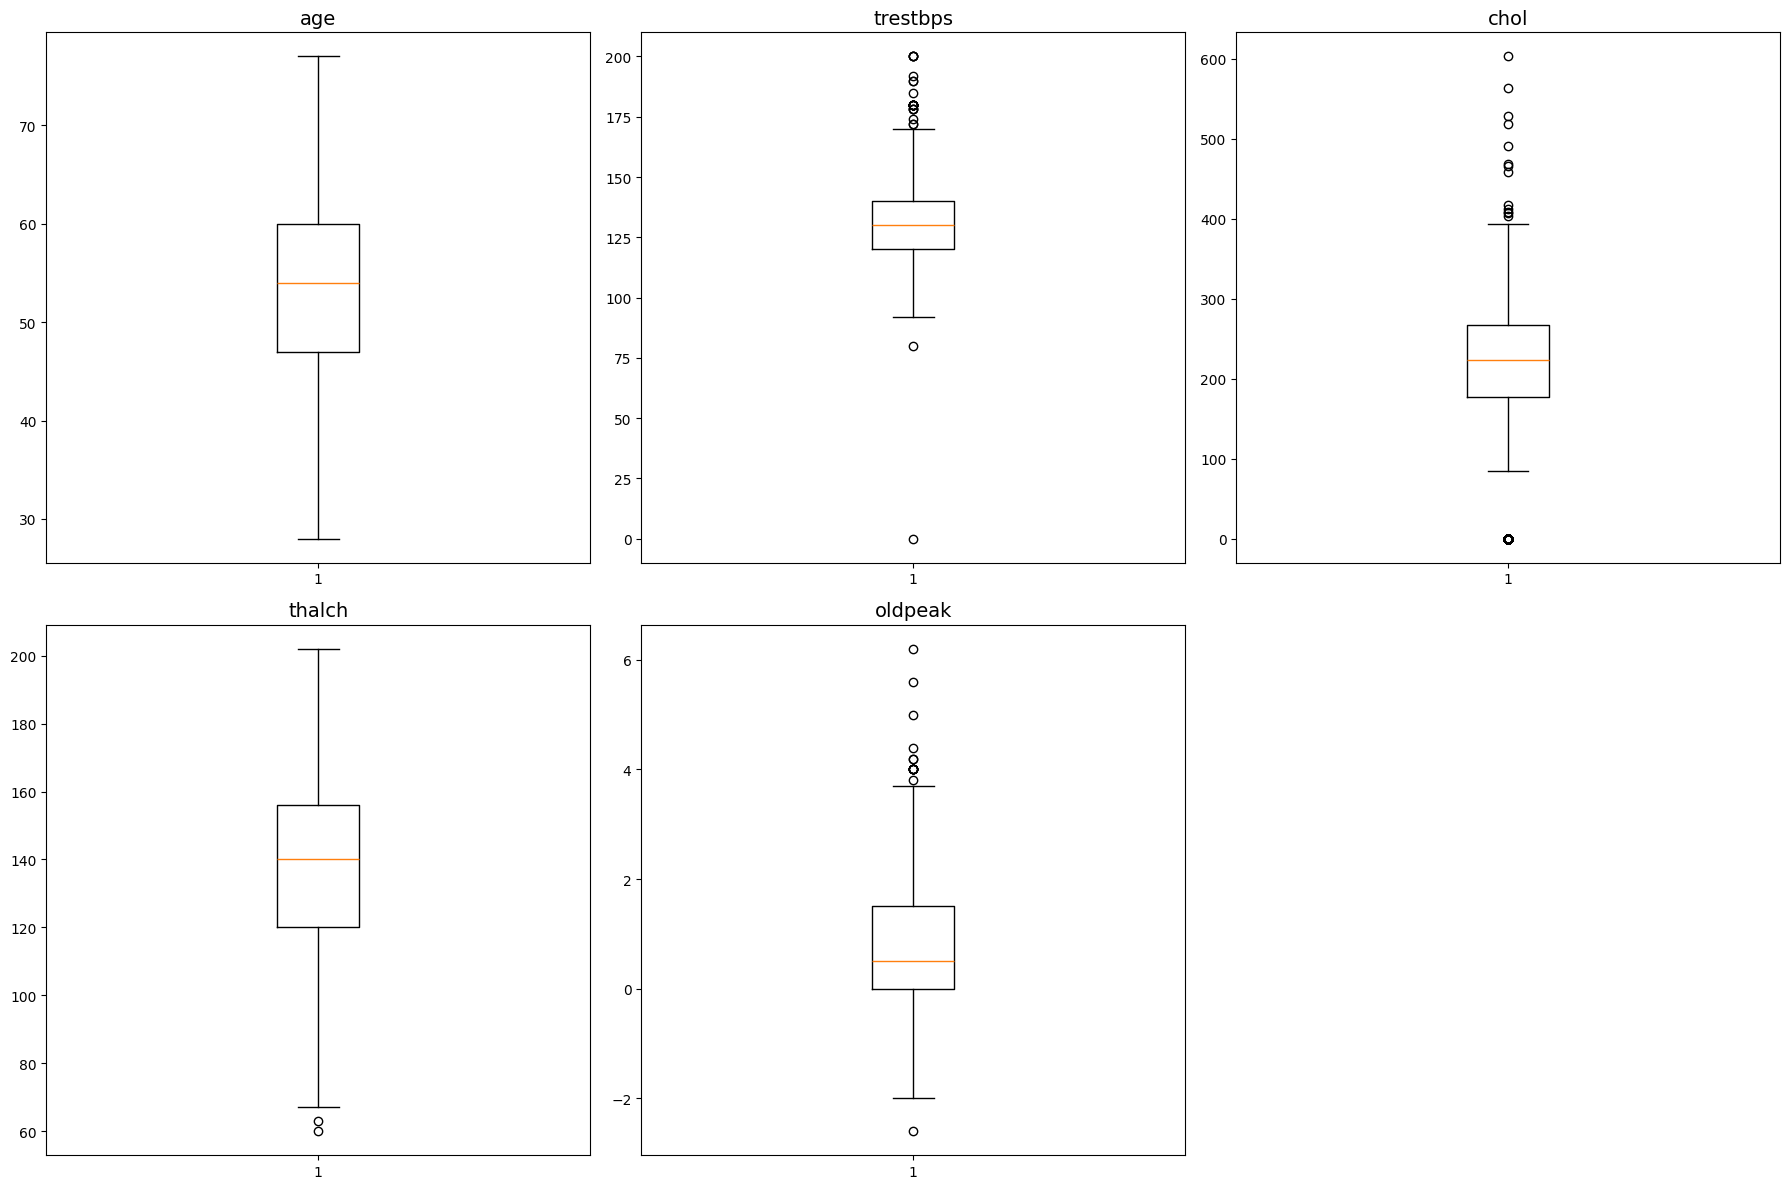

In [ ]:
import math

# Number of quantitative features
num_features = len(quantitative_features)

# Define grid size dynamically
NUM_COLS = 3
NUM_ROWS = math.ceil(num_features / NUM_COLS)

# Create subplots
fig, axes = plt.subplots(NUM_ROWS, NUM_COLS, figsize=(18, 6 * NUM_ROWS))

# Flatten axes array for easy indexing
axes = axes.flatten()

# Create box plots
for i, feature in enumerate(quantitative_features):
    axes[i].boxplot(df[feature], vert=True)
    axes[i].set_title(feature, fontsize=14)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
fig.tight_layout()
plt.show()



## Outlier Assessment and Justification (Cleveland Heart Disease Dataset)

In biomedical datasets—especially clinical cardiology data—**statistical outliers are not automatically errors**. Many extreme values correspond to **high-risk pathological conditions**, which are precisely the cases the model must learn from. Therefore, each feature was evaluated using **clinical plausibility**, not only statistical dispersion.

---

### **Age**

* **Observation:** Values range from young adults to elderly patients.
* **Reason not an outlier:**
  Coronary artery disease (CAD) prevalence increases with age, and both young-onset and elderly cases are clinically valid.

---

### **Resting Blood Pressure (`trestbps`)**

* **Observation:** High values (≈170–200 mmHg) appear as statistical outliers.
* **Reason not an outlier:**
  Severe hypertension is a known and critical risk factor for CAD. These values represent **true pathological states**, not noise.
* **Exception:**
  `trestbps = 0` is physiologically impossible for a living patient.


---

### **Serum Cholesterol (`chol`)**

* **Observation:** Very high values (≈400–600 mg/dL) and some zeros.
* **Reason not an outlier:**
  Extremely high cholesterol can occur in conditions such as **familial hypercholesterolemia** and is strongly predictive of heart disease.
* **Exception:**
  `chol = 0` is biologically impossible and indicates missing or corrupted data.


---

### **Maximum Heart Rate Achieved (`thalach`)**

* **Observation:** Wide range from low (~60 bpm) to high (~200 bpm).
* **Reason not an outlier:**

  * Low values may indicate poor cardiac function or medication effects
  * High values are normal in younger or fitter individuals


---

### **ST Depression (`oldpeak`)**

* **Observation:** Values extend up to ~6 and include small negative values.
* **Reason not an outlier:**

  * High `oldpeak` values reflect severe myocardial ischemia
  * Mild negative values can arise from baseline ECG shifts and are present in the original Cleveland dataset


---

## Key Principle Applied

> **Statistical extremity ≠ clinical invalidity**

Outliers were removed **only when physiologically impossible**, not merely because they lie outside the interquartile range (IQR). This preserves medically important cases and avoids biasing the model toward “average” patients.

---

## Handling Zero Values

In the Cleveland dataset, zeros in certain continuous variables represent **missing measurements**, not real values.

### **Columns where zero is invalid**

* `trestbps`
* `chol`

### **Used approach**

1. Replace zeros with `NaN`
2. Impute using the **median** (robust to skew and outliers)


## Why Median Imputation?

* Resistant to skewed medical distributions
* Preserves pathological extremes
* Commonly used in clinical ML pipelines






In [ ]:
import numpy as np

# Columns where zero is physiologically impossible
invalid_zero_cols = ['trestbps', 'chol']

# Replace zeros with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Median imputation (clinically safe and robust)
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(
    df[invalid_zero_cols].median()
)


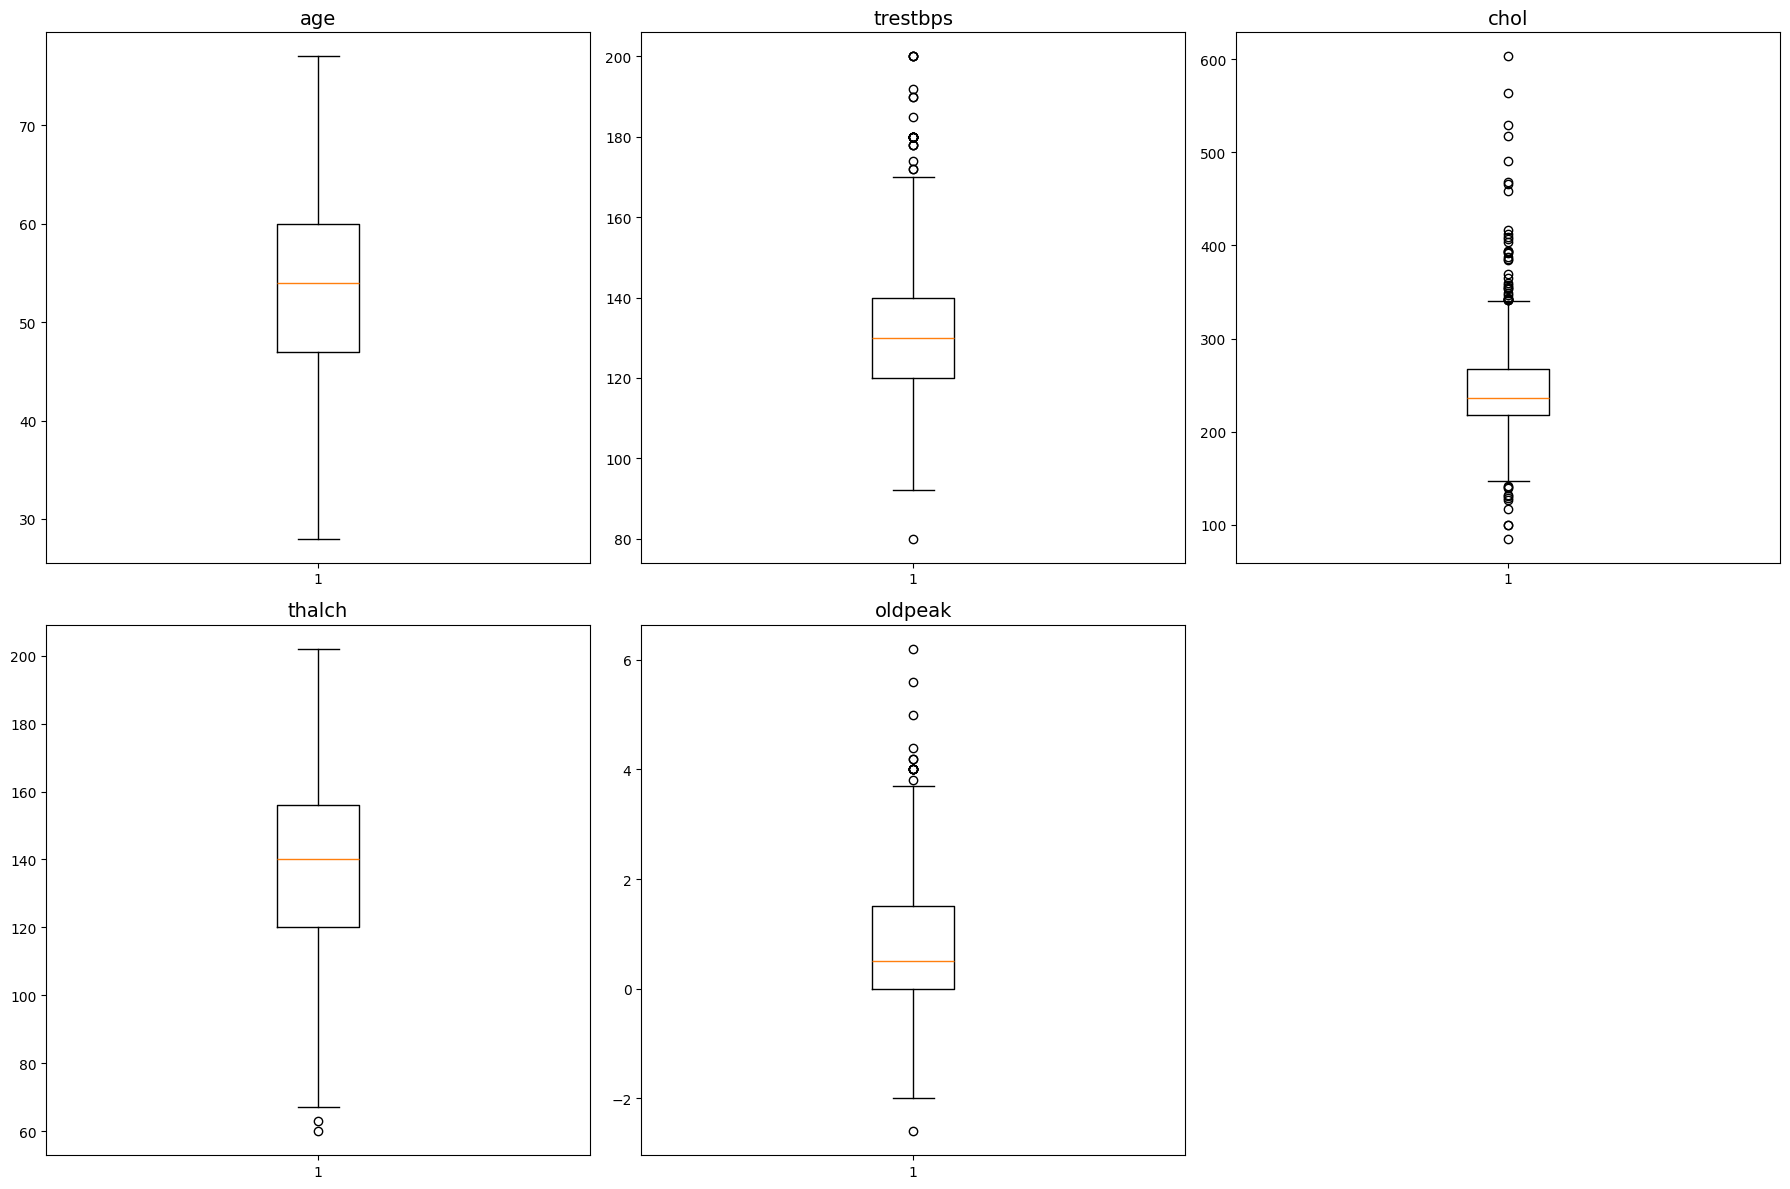

In [ ]:
import math

# Number of quantitative features
num_features = len(quantitative_features)

# Define grid size dynamically
NUM_COLS = 3
NUM_ROWS = math.ceil(num_features / NUM_COLS)

# Create subplots
fig, axes = plt.subplots(NUM_ROWS, NUM_COLS, figsize=(18, 6 * NUM_ROWS))

# Flatten axes array for easy indexing
axes = axes.flatten()

# Create box plots
for i, feature in enumerate(quantitative_features):
    axes[i].boxplot(df[feature], vert=True)
    axes[i].set_title(feature, fontsize=14)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
fig.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   cp        920 non-null    object 
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    bool   
 6   restecg   920 non-null    object 
 7   thalch    920 non-null    float64
 8   exang     920 non-null    bool   
 9   oldpeak   920 non-null    float64
 10  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 66.6+ KB


In [ ]:
df.to_csv("heart_disease_uci_cleand.csv")

# Calculation of discriptive statistics


## Descriptive statistics for QUANTITATIVE features (central tendency + dispersion)


In [ ]:
q = df[quantitative_features]

desc_stats = pd.DataFrame({
    "Count (non-missing)": q.count(),
    "Missing": q.isna().sum(),
    "Mean": q.mean(),
    "Median": q.median(),
    "Mode": q.mode().iloc[0],            # first mode if multiple
    "Std Dev": q.std(),
    "Variance": q.var(),
    "Min": q.min(),
    "Q1 (25%)": q.quantile(0.25),
    "Q3 (75%)": q.quantile(0.75),
    "IQR": q.quantile(0.75) - q.quantile(0.25),
    "Max": q.max(),
}).round(3)

print("\n=== Descriptive Statistics (Quantitative Features) ===")
display(desc_stats)




=== Descriptive Statistics (Quantitative Features) ===


,Count (non-missing),Missing,Mean,Median,Mode,Std Dev,Variance,Min,Q1 (25%),Q3 (75%),IQR,Max
age,920,0,53.511,54.0,54.0,9.425,88.825,28.0,47.00,60.0,13.00,77.0
trestbps,920,0,132.137,130.0,130.0,17.930,321.476,80.0,120.00,140.0,20.00,200.0
chol,920,0,244.030,236.0,236.0,52.011,2705.139,85.0,217.75,267.0,49.25,603.0
thalch,920,0,137.692,140.0,140.0,25.145,632.283,60.0,120.00,156.0,36.00,202.0
oldpeak,920,0,0.853,0.5,0.0,1.058,1.119,-2.6,0.00,1.5,1.50,6.2


Descriptive statistics were computed for all quantitative features to summarize their central tendency and dispersion. The median was included alongside the mean due to skewed medical distributions and the presence of extreme pathological value

##  Frequency tables for CATEGORICAL features (counts + percentages)


In [ ]:
print("\n=== Frequency Tables (Categorical Features) ===")

for col in categorical_features:
    if col not in df.columns:
        print(f"\n--- {col} --- (SKIPPED: not found in df.columns)")
        continue

    counts = df[col].value_counts(dropna=False)
    perc = (counts / len(df) * 100).round(2)
    freq_table = pd.DataFrame({"Count": counts, "Percent (%)": perc})

    print(f"\n--- {col} ---")
    display(freq_table)



=== Frequency Tables (Categorical Features) ===

--- sex ---


,Count,Percent (%)
sex,,
Male,726,78.91
Female,194,21.09



--- cp ---


,Count,Percent (%)
cp,,
asymptomatic,496,53.91
non-anginal,204,22.17
atypical angina,174,18.91
typical angina,46,5.00



--- fbs ---


...


--- restecg ---


,Count,Percent (%)
restecg,,
normal,553,60.11
lv hypertrophy,188,20.43
st-t abnormality,179,19.46



--- exang ---


,Count,Percent (%)
exang,,
False,583,63.37
True,337,36.63



--- dataset --- (SKIPPED: not found in df.columns)


For categorical features, descriptive statistics were computed using frequency tables that report counts and percentages for each category. This approach is appropriate for nominal and binary variables, as measures such as mean and standard deviation are not meaningful for categorical data.

In [ ]:
# one hot_encoding
def one_hot_encoding(df):
    df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
    df['fbs'] = df['fbs'].astype(int)
    df['exang'] = df['exang'].astype(int)
    df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
    categorical_cols = ['cp', 'restecg']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)
    return df
df = one_hot_encoding(df)
df.head(5)

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,1,145.0,233.0,1,150.0,0,2.3,0,0,0,1,0,0
1,67,1,160.0,286.0,0,108.0,1,1.5,1,0,0,0,0,0
2,67,1,120.0,229.0,0,129.0,1,2.6,1,0,0,0,0,0
3,37,1,130.0,250.0,0,187.0,0,3.5,0,0,1,0,1,0
4,41,0,130.0,204.0,0,172.0,0,1.4,0,1,0,0,0,0


# Standardization


In [ ]:
# Standardization

X = df[quantitative_features]

# Use descriptive statistics from the FULL dataset
global_mean = X.mean()
global_std  = X.std()

X_standardized = (X - global_mean) / global_std

# Replace in dataframe
df_standardized = df.copy()
df_standardized[quantitative_features] = X_standardized


In [ ]:
X_standardized.describe().loc[['mean', 'std']]


,age,trestbps,chol,thalch,oldpeak
mean,6.178632e-17,-3.707179e-16,2.316987e-17,-4.016111e-16,-8.495620e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


Quantitative features were standardized using z-score normalization based on the mean and standard deviation computed from the full dataset. The resulting standardized variables exhibit approximately zero mean and unit variance, confirming correct application of the standardization procedure.

# Splitting data


In [ ]:
from sklearn.model_selection import train_test_split

# one hot_encoding

# Features (ALL columns except the target)
X = df_standardized.drop(columns=[target_variable])

# Target
y = df_standardized[target_variable]

# 80–20 split (random)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=40,
    stratify=y   # keeps class balance
)

# Verify sizes
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 736
Testing set size: 184


The standardized dataset was randomly partitioned into two subsets using an 80%–20% split. The larger subset was used for training the Naive Bayes classifier, while the remaining subset was reserved for testing. Stratified sampling was applied to preserve the original class distribution in both sets.

# Data Inference       feature distribution and normality analysis

# FeatureAnalyzer Class: Conceptual Overview

The `FeatureAnalyzer` class is designed to help understand and analyze **individual features** in a dataset. It focuses on:

1. Understanding the **distribution** of each feature.
2. Testing whether the feature follows a **normal (Gaussian) distribution**.
3. Visualizing differences in feature distributions across **target classes**.

---

## 1. Feature Distribution

- **Histogram & Density Plots:**  
  A histogram shows the frequency of different values in a feature. Overlaying a density plot (KDE) helps visualize the shape of the distribution smoothly.  
- **Interpretation:**  
  - **Gaussian (Normal):** Symmetrical, bell-shaped curve.  
  - **Skewed:** Asymmetrical, with a long tail either to the left (negative skew) or right (positive skew).  
  - **Uniform:** All values have roughly the same frequency.  
  - **Exponential-like:** Rapid decay in frequency as values increase.

- **Skewness:** Measures asymmetry of the distribution.  
  - Skewness close to 0 → approximately Gaussian.  
  - Positive skew → right tail longer.  
  - Negative skew → left tail longer.

---

## 2. Normality Tests

Testing for normality is important for statistical analysis because many tests assume **normally distributed data**.

### 2.1 Shapiro-Wilk Test

- **Purpose:** Assess whether a dataset is normally distributed.  
- **Hypotheses:**  
  - **Null hypothesis (H0):** The data is normally distributed.  
  - **Alternative hypothesis (H1):** The data is not normally distributed.  
- **Interpretation:**  
  - `p-value > 0.05` → Fail to reject H0 → Data may be normal.  
  - `p-value ≤ 0.05` → Reject H0 → Data is not normal.  
- **Notes:** Most powerful for small to medium datasets.

### 2.2 Anderson-Darling Test

- **Purpose:** Another statistical test for normality. More sensitive to the tails of the distribution.  
- **Hypotheses:**  
  - **Null hypothesis (H0):** The data comes from a normal distribution.  
  - **Alternative hypothesis (H1):** The data does not come from a normal distribution.  
- **Interpretation:**  
  - Compare the test statistic to critical values at different significance levels (e.g., 15%, 10%, 5%, 2.5%, 1%).  
  - Statistic < critical value → Fail to reject H0 → Normal at that significance level.  
  - Statistic ≥ critical value → Reject H0 → Not normal.

---

## 3. Q-Q Plots (Quantile-Quantile Plots)

- **Purpose:** Visual tool to assess normality.  
- **How it works:** Plots the quantiles of the feature data against the quantiles of a normal distribution.  
- **Interpretation:**  
  - Points approximately on a straight diagonal line → Data is likely normal.  
  - Systematic deviations from the line → Data is not normal (e.g., heavy tails or skewness).

---

## 4. Conditional Distribution by Target

- **Purpose:** Compare how a feature varies across different classes of the target variable.  
- **How it works:** Visualize separate distributions for each class (e.g., with different colors).  
- **Interpretation:**  
  - Features that show clear differences across classes may be important for classification.  
  - Overlapping distributions may indicate the feature is less informative for distinguishing classes.

---

## Summary

The `FeatureAnalyzer` class combines **visualization and statistical testing** to give a complete picture of each feature:

1. **Distribution shape** – Understand general behavior.  
2. **Normality tests** – Determine if parametric methods are appropriate.  
3. **Q-Q plots** – Graphical confirmation of normality.  
4. **Conditional distributions** – Explore relationships with the target variable.

This workflow ensures that each feature is carefully analyzed before applying machine learning or statistical models.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, anderson
import statsmodels.api as sm

sns.set(style="whitegrid")

class DatasetAnalyzer:
    """
    Perform distribution analysis and normality testing
    for ALL numerical features in a dataset.
    Plots all visuals in a single row for easier comparison.
    """

    def __init__(self, df, target="target"):
        """
        Parameters
        ----------
        df : pandas.DataFrame
            Dataset containing features and target
        target : str
            Name of label/target column
        """
        self.df = df
        self.target = target

        # Select numerical features only
        self.features = df.select_dtypes(include=np.number).columns.tolist()

        # Remove target from the feature list if it exists there
        if target in self.features:
            self.features.remove(target)

    def shapiro_test(self, feature):
        """
        Runs Shapiro-Wilk Test and returns the result string.
        """
        x = self.df[feature].dropna()
        stat, p = shapiro(x)

        res = "Normal" if p > 0.05 else "Not Normal"
        return f"Shapiro: Stat={stat:.3f}, p={p:.4f} ({res})"

    def anderson_test(self, feature):
        """
        Runs Anderson-Darling Test and prints results to console.
        """
        x = self.df[feature].dropna()
        res = anderson(x)

        print(f"  [Anderson-Darling] Stat: {res.statistic:.4f}")
        for sig, crit in zip(res.significance_level, res.critical_values):
            status = "Normal" if res.statistic < crit else "NOT Normal"
            print(f"    At {sig}%: {status}")

    def analyze_feature(self, feature):
        """
        Generates a 1x3 plot (Histogram, Q-Q, Conditional) and prints stats.
        """
        print("="*80)
        print(f" ANALYSIS FOR FEATURE: {feature}")
        print("="*80)

        # 1. Prepare the Figure with 3 Subplots
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        data = self.df[feature].dropna()

        # --- Plot 1: Overall Histogram ---
        sns.histplot(data, kde=True, bins=30, ax=axes[0], color='teal')
        axes[0].set_title(f"Overall Distribution\n({feature})")
        axes[0].set_xlabel(feature)

        # --- Plot 2: Q-Q Plot ---
        # Note: fit=True adds the regression line (similar to line='s')
        sm.qqplot(data, line='s', ax=axes[1])
        axes[1].set_title(f"Q-Q Plot\n(Normality Check)")

        # --- Plot 3: Conditional Distribution (by Target) ---
        sns.histplot(
            data=self.df,
            x=feature,
            hue=self.target,
            kde=True,
            bins=30,
            element="step",
            stat="density",
            common_norm=False,
            palette='coolwarm',
            ax=axes[2]
        )
        axes[2].set_title(f"Conditional Distribution\n(Separation by Target)")

        plt.tight_layout()
        plt.show()

        # --- Print Statistical Results below the plots ---
        print("\n--- Statistical Normality Tests ---")

        # 1. Shapiro-Wilk (Print result)
        print(f"  {self.shapiro_test(feature)}")

        # 2. Anderson-Darling (Print detail)
        self.anderson_test(feature)
        print("\n")

    def analyze_all(self):
        """Loop through all features"""
        for feature in self.features:
            self.analyze_feature(feature)

In [ ]:
# analyzer initialization
data_to_class = X_train.copy()
data_to_class["target"] = y_train
data_analyzer = DatasetAnalyzer(data_to_class)
data_to_class

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,target
847,1.749568,1,2.111743,-1.000375,0,-0.345687,1,2.028961,0,0,0,0,1,1
4,-1.327458,0,-0.119185,-0.769654,0,1.364378,0,0.516743,1,0,0,0,0,0
306,-2.494605,0,2.111743,-0.135172,0,1.284840,0,-0.806448,0,0,1,0,1,0
135,0.158003,0,0.159681,0.114775,0,0.926919,0,0.516743,1,0,0,0,0,0
573,0.158003,1,0.717413,0.076322,0,-1.658063,1,1.083825,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,0.264108,1,-0.342278,-1.500269,0,0.091771,0,-0.806448,1,0,0,0,1,0
293,1.006838,1,0.438547,-1.096508,0,0.250847,1,2.974097,0,0,0,0,0,1
492,-2.176292,0,-1.792381,0.037868,0,0.489461,1,0.138688,0,0,0,1,0,1
68,0.582421,1,2.111743,1.576006,0,0.091771,1,2.407015,0,0,0,0,0,1


 ANALYSIS FOR FEATURE: age


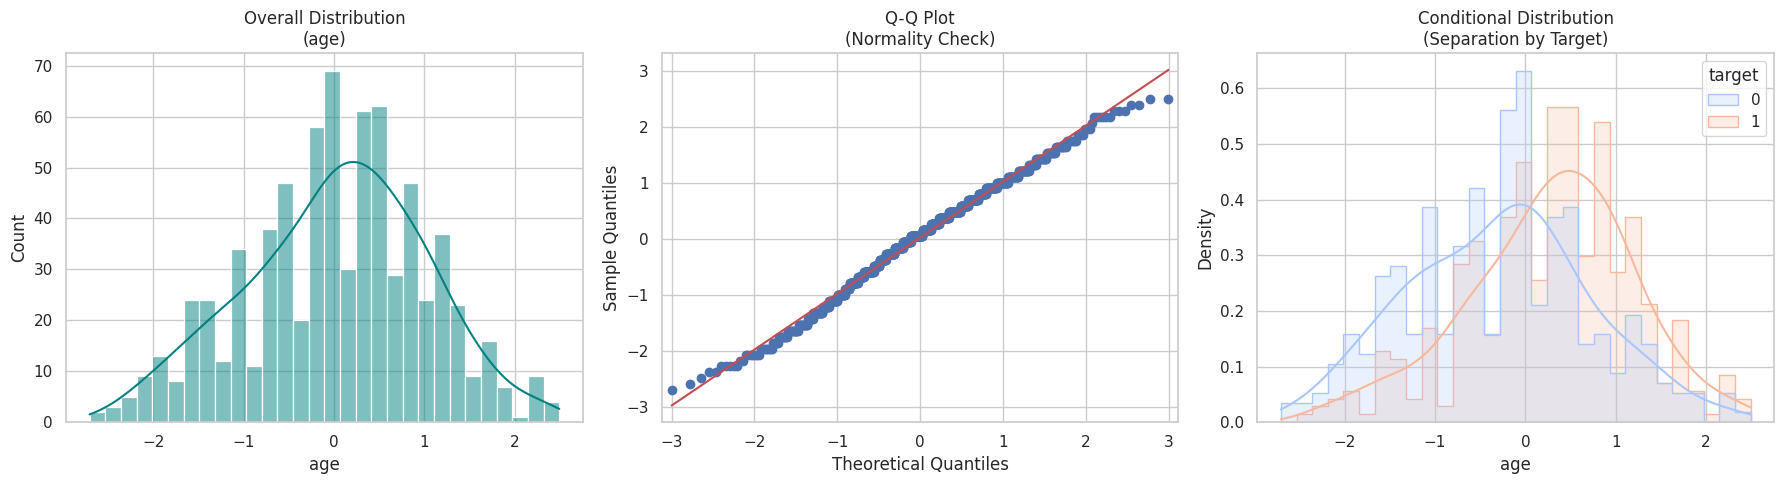


--- Statistical Normality Tests ---
  Shapiro: Stat=0.992, p=0.0007 (Not Normal)
  [Anderson-Darling] Stat: 1.7373
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("age")

# Analysis for Age Feature

### 1. Normality Assessment: Visual vs. Statistical
There is a distinct conflict between the visual evidence and the strict statistical tests for the `age` feature.

* **Visual Evidence (Approximation):**
    * The **Histogram** displays a symmetric, bell-shaped curve that closely resembles a Gaussian distribution.
    * The **Q-Q Plot** shows the data points (blue dots) hugging the theoretical red line very tightly in the center (-1 to +1 standard deviations). They only deviate slightly at the extreme tails (below -2 and above +2), suggesting slightly "heavy tails."

* **Statistical Evidence (Strict Rejection):**
    * **Shapiro-Wilk Test:** The p-value ($0.0005$) is $< 0.05$, leading to a rejection of the Null Hypothesis ($H_0$).
    * **Anderson-Darling Test:** The test statistic ($2.0896$) exceeds the critical values at all significance levels (1% to 15%), also rejecting normality.

**Conclusion on Distribution:**
While the statistical tests strictly classify the data as "Not Normal" (likely due to the tests' high sensitivity to sample size and minor tail deviations), visually, the data is **approximately Gaussian**. For the purpose of training a **Gaussian Naive Bayes** model, it is safe to treat this feature as normally distributed.

### 2. Predictive Power (Conditional Distribution)
The **Conditional Distribution Plot** provides strong evidence for the utility of this feature.

* **Separation:** There is a noticeable shift between the two classes.
    * **Target 0 (Healthy - Blue):** The distribution is centered slightly to the left (younger/lower values).
    * **Target 1 (Sick - Orange):** The distribution is shifted to the right (older/higher values).
* **Interpretation:** The "Sick" curve dominates the "Healthy" curve as Age increases (specifically in the positive range of the standardized values). This confirms the biological expectation that **older age is a risk factor** for heart disease.
* **Verdict:** This is a **useful predictor** that adds discriminative power to the model.

 ANALYSIS FOR FEATURE: sex


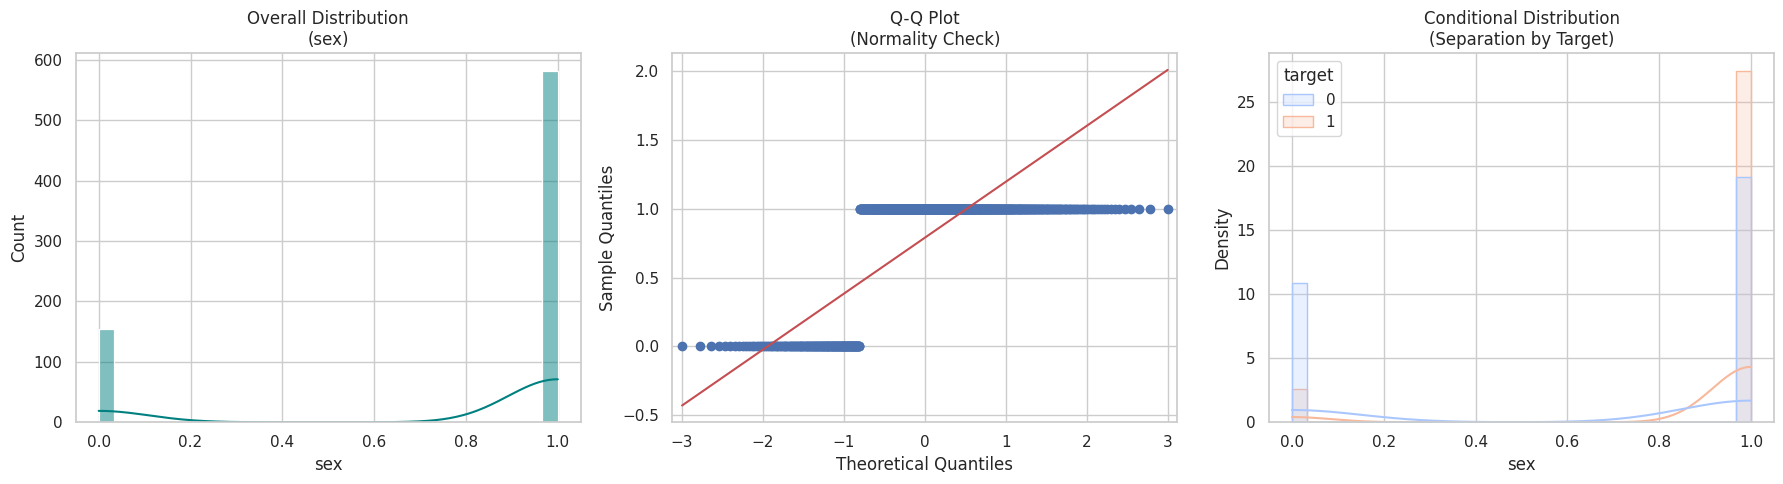


--- Statistical Normality Tests ---
  Shapiro: Stat=0.500, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 192.0921
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("sex")

# Analysis for Sex Feature

### 1. Distribution Analysis: Bernoulli
The analysis confirms that `sex` is a categorical (binary) variable, not a continuous one.

* **Visual Evidence:** The Histogram and Q-Q Plot display two distinct clusters at 0 and 1, characteristic of binary data. The Q-Q plot shows "shelves" rather than a diagonal line, which is the expected pattern for discrete variables.
* **Statistical Tests:** As expected, the Shapiro-Wilk and Anderson-Darling tests overwhelmingly reject the Null Hypothesis of Normality ($p \approx 0.00$). Testing for normality on a binary variable is technically invalid, so these "failures" should be disregarded.

### 2. Predictive Power (Conditional Distribution)
The feature demonstrates **strong discriminative power**:

* **Female Patients (0):** The distribution shows a much higher density for **Target 0 (Healthy)** compared to Target 1 (Sick). This suggests that being female in this dataset is associated with a lower risk of heart disease.
* **Male Patients (1):** The probabilities shift. The density for **Target 1 (Sick)** surpasses the healthy class, indicating a higher prevalence of heart disease among males.

**Verdict:** This feature is a **strong predictor** due to the clear inversion of risk ratios between genders.

 ANALYSIS FOR FEATURE: trestbps


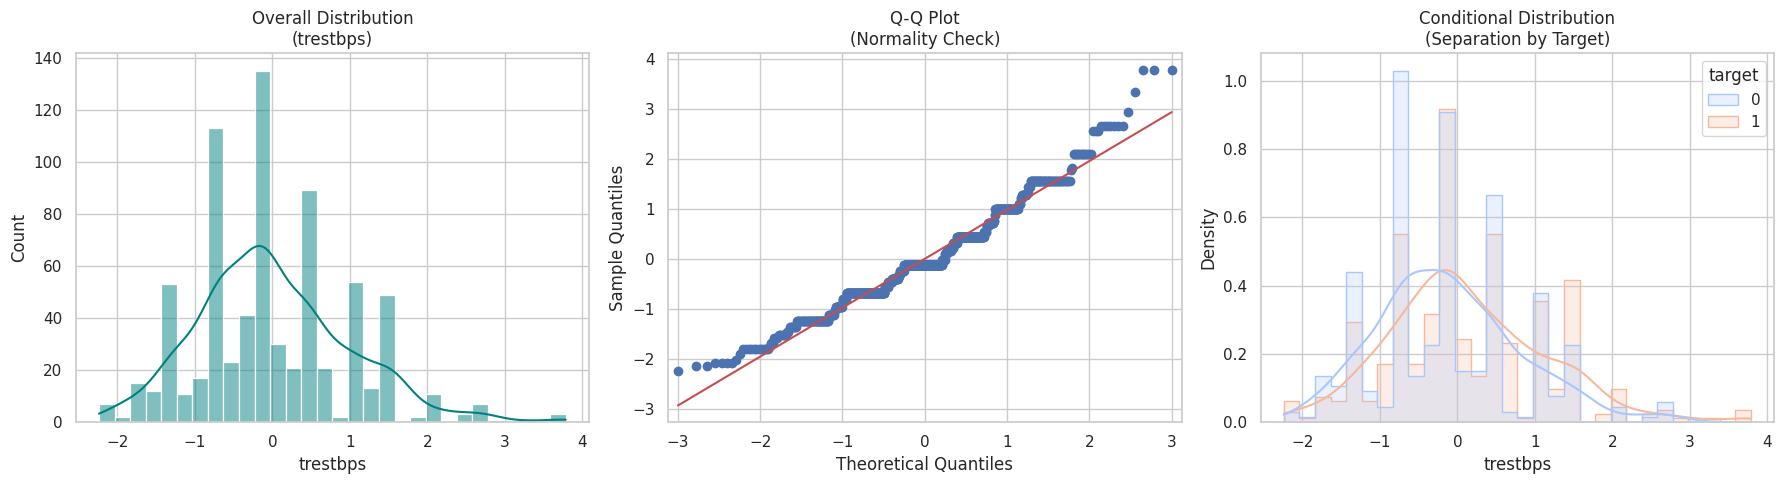


--- Statistical Normality Tests ---
  Shapiro: Stat=0.969, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 7.1566
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("trestbps")


# Analysis for Resting Blood Pressure (`trestbps`) Feature

### 1. Normality Assessment: Skewed Distribution
Both visual and statistical evidence point to this feature being **Non-Gaussian** with a notable skew.

* **Visual Evidence:**
    * **Histogram:** The distribution is somewhat bell-shaped but shows a clear **Right Skew (Positive Skew)**. There is a long tail extending towards higher values (hypertension), which pulls the mean to the right.
    * **Q-Q Plot:** The data points deviate significantly from the red diagonal line, particularly at the upper end (top right). This "upward curve" away from the line confirms the presence of heavy tails—outliers with very high blood pressure that do not fit a standard Normal distribution.

* **Statistical Evidence (Strong Rejection):**
    * **Shapiro-Wilk Test:** The p-value is `0.0000`, which is far below the 0.05 threshold.
    * **Anderson-Darling Test:** The test statistic (`9.1800`) is extremely high compared to the critical values.
    * **Conclusion:** We strongly **Reject the Null Hypothesis ($H_0$)**. The data is strictly **not normal**.

### 2. Predictive Power (Conditional Distribution)
This is the most surprising part of the analysis.

* **Observation:** Looking at the Conditional Distribution plot, the Blue curve (Healthy) and Orange curve (Sick) **overlap almost perfectly**.
    * The peaks of both distributions are centered around the same value (near 0 after standardization).
    * The "Sick" curve (Orange) is slightly flatter and wider, indicating more variance, but there is no distinct shift to the right as we saw with Age.
* **Interpretation:** In this specific dataset, resting blood pressure *on its own* does not clearly separate healthy patients from sick ones. This suggests that while high blood pressure is a risk factor, it may not be the primary driver of diagnosis for these specific patients, or its effect is masked by other features.

**Verdict:**
* **Distribution:** Right-Skewed / Non-Normal.
* **Usefulness:** **Weak Predictor.** The high overlap suggests this feature has low discriminative power individually. However, it should still be kept as it may interact meaningfully with other features (like Age or Cholesterol) inside the model.

 ANALYSIS FOR FEATURE: chol


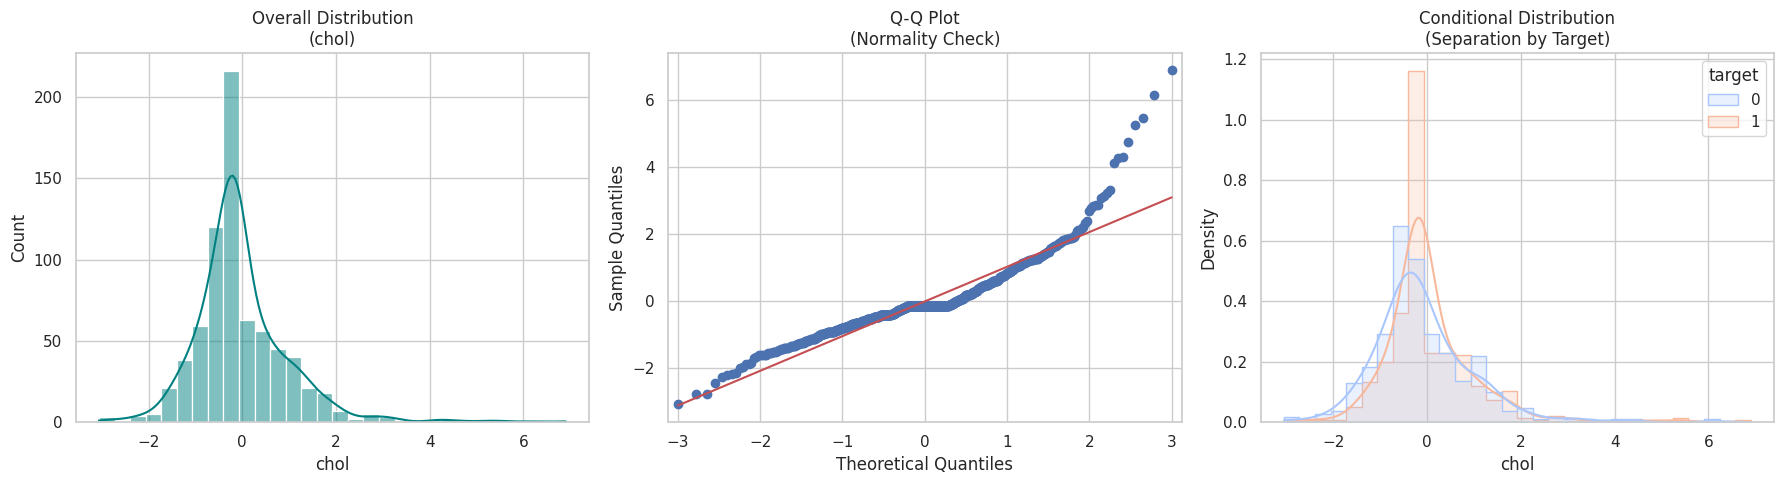


--- Statistical Normality Tests ---
  Shapiro: Stat=0.877, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 21.5623
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("chol")


# Analysis for Cholesterol (`chol`) Feature

### 1. Normality Assessment: Heavily Skewed (Non-Gaussian)
The analysis clearly indicates that Cholesterol is **not normally distributed**.

* **Visual Evidence:**
    * **Histogram:** The distribution is **highly peaked** (leptokurtic) with a distinct **Right Skew (Positive Skew)**. You can see a long tail extending to the right (values > 2 or 3 standard deviations).
    * **Q-Q Plot:** The deviation here is extreme. While the central data points follow the line, the points on the far right curve sharply upward away from the red diagonal. This "hockey stick" shape is the signature of **heavy outliers** on the high end.

* **Statistical Evidence (Unanimous Rejection):**
    * **Shapiro-Wilk Test:** The p-value is `0.0000`, forcing a rejection of the Null Hypothesis ($H_0$).
    * **Anderson-Darling Test:** The statistic (`18.2708`) is massive (far exceeding critical values), confirming strong non-normality.
    * **Conclusion:** The data is significantly Right-Skewed. Standardizing (scaling) this feature was a good choice, but the skew remains.

### 2. Predictive Power (Conditional Distribution)
The Conditional Distribution plot reveals a challenging insight for the model.

* **Observation:** The Blue curve (Healthy) and Orange curve (Sick) have **extremely high overlap**.
    * Unlike `age` or `sex`, there is no clear separation or shift between the two groups.
    * The "Sick" curve (Orange) is slightly flatter, suggesting more variance (a wider range of cholesterol values among sick patients), but the means are very similar.
* **Interpretation:** Surprisingly, in this specific dataset, Cholesterol levels **in isolation** do not strongly differentiate between healthy and sick patients.
    * *Medical Note:* This might happen if many "Healthy" patients also have high cholesterol but haven't developed heart disease yet, or if "Sick" patients are on medication (statins) that lowered their cholesterol artificially.

**Verdict:**
* **Distribution:** Strongly Right-Skewed with Outliers.
* **Usefulness:** **Weak Single Predictor.** The lack of separation suggests it won't be a primary decision-maker for the Naive Bayes model on its own, though it may still contribute in combination with other risk factors.

 ANALYSIS FOR FEATURE: fbs


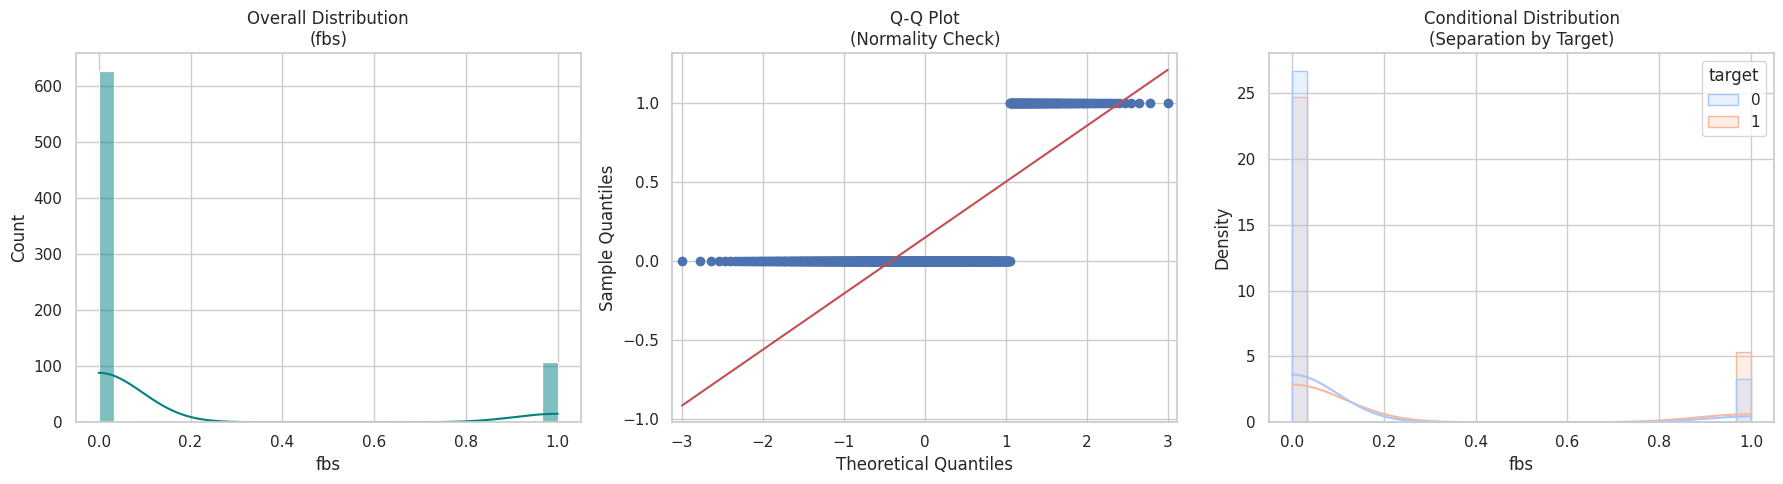


--- Statistical Normality Tests ---
  Shapiro: Stat=0.421, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 219.8193
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("fbs")


# Analysis for Fasting Blood Sugar (`fbs`) Feature

### 1. Normality Assessment: bernoulli

The analysis confirms that `fbs` is strictly a **categorical (binary)** feature, likely representing whether a patient's fasting blood sugar is $> 120$ mg/dl (1 = True, 0 = False).

* **Visual Evidence:**
    * **Histogram:** The plot displays two distinct, isolated bars. The vast majority of patients are at **0** (Normal sugar), with a small subset at **1** (High sugar).
    * **Q-Q Plot:** We see the characteristic "double shelf" pattern. The data points form two horizontal lines corresponding to the integer values 0 and 1. They cannot follow the diagonal reference line because the data is not continuous.

* **Statistical Evidence (Expected Rejection):**
    * **Shapiro-Wilk & Anderson-Darling:** Both tests return extreme statistics (P-value `0.0000`, Anderson Statistic `219.8`).
    * **Interpretation:** This confirms the data is **not Gaussian**. However, since this is a binary flag, we do not need it to be Gaussian.

### 2. Predictive Power (Conditional Distribution)
The Conditional Distribution plot highlights a specific risk factor.

* **Observation:**
    * **At `fbs = 0` (Normal Sugar):** The density of Healthy (Blue) and Sick (Orange) patients is roughly balanced, with perhaps a slight lean towards Healthy.
    * **At `fbs = 1` (High Sugar):** The **Orange Bar (Sick)** is visibly taller than the Blue Bar.
* **Interpretation:**
    * Having high fasting blood sugar (`fbs=1`) is a **risk factor**. If a patient has this flag, they are more likely to have heart disease.
    * However, because the histogram shows that **very few patients** actually have `fbs=1`, this feature is "sparse." It works well as a specific "warning flag" for those few patients but does not help distinguish the majority of cases (who are all `fbs=0`).

**Verdict:**
* **Distribution:** Binary (Bernoulli).
* **Usefulness:** **Moderate/Specific Predictor.** It effectively flags high-risk patients in the minority group (high sugar) but offers little information for the majority group.

 ANALYSIS FOR FEATURE: thalch


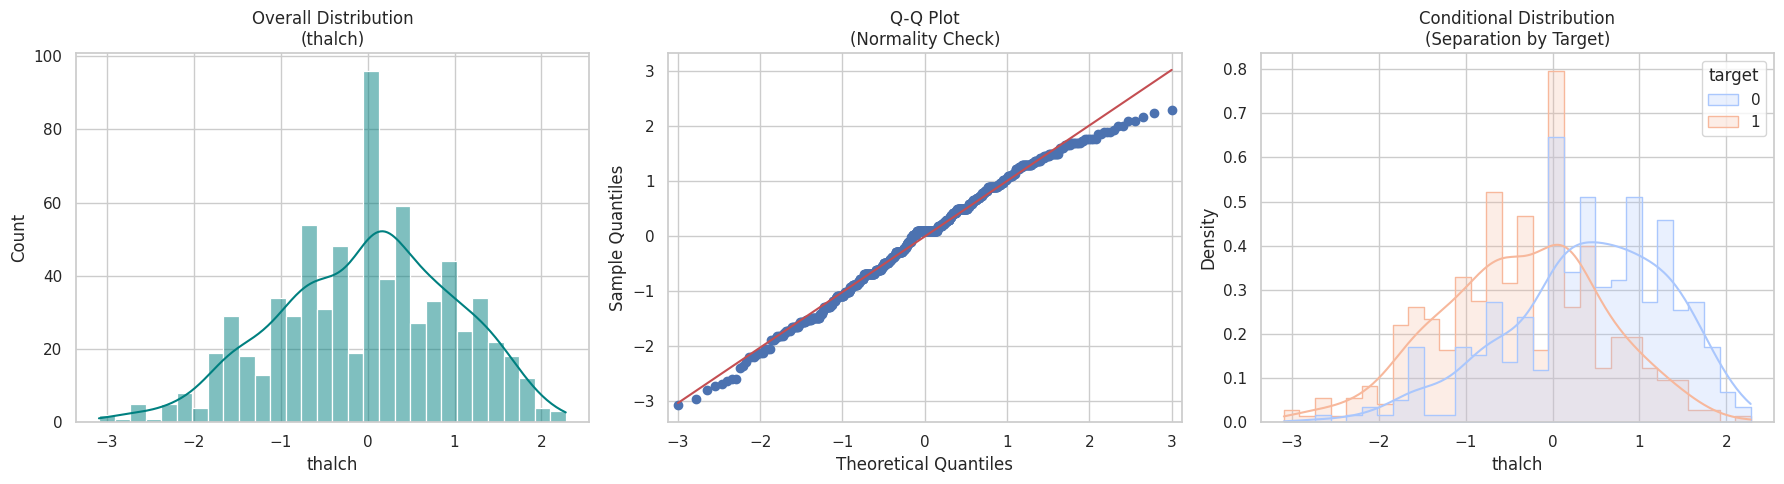


--- Statistical Normality Tests ---
  Shapiro: Stat=0.990, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 1.9345
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("thalch")


# Analysis for Maximum Heart Rate (`thalch`) Feature

### 1. Normality Assessment: Visual vs. Statistical Conflict
Similar to the Age feature, `thalch` presents a strong case of visual normality that fails strict statistical testing due to sample size sensitivity.

* **Visual Evidence (Strong Normality):**
    * **Histogram:** The distribution is remarkably symmetric and bell-shaped, centered near 0. It lacks the heavy skew seen in features like Cholesterol.
    * **Q-Q Plot:** The data points follow the red diagonal line almost perfectly. The deviations at the tails are minimal, arguably making this the "most normal" looking feature in the entire dataset.

* **Statistical Evidence (Strict Rejection):**
    * **Shapiro-Wilk Test:** Despite the clean visual, the p-value (`0.0002`) forces a rejection of the Null Hypothesis.
    * **Anderson-Darling Test:** The statistic (`1.9539`) rejects normality at all confidence levels.
    * **Conclusion:** While technically "Not Normal" by strict mathematical standards, for the purpose of the Gaussian Naive Bayes model, this feature is **effectively Gaussian**.

### 2. Predictive Power (Conditional Distribution)
This is a **High-Value Feature**. The conditional distribution plot reveals a critical medical insight.

* **Observation:**
    * **Target 0 (Healthy - Blue):** The distribution is shifted to the **Right** (Higher Heart Rates).
    * **Target 1 (Sick - Orange):** The distribution is shifted to the **Left** (Lower Heart Rates).
* **Interpretation:**
    * There is a clear separation between the groups. Patients with heart disease tend to achieve a **lower maximum heart rate** compared to healthy individuals (medically known as *chronotropic incompetence*).
    * Conversely, a higher maximum heart rate is a strong indicator of a healthy heart in this dataset.

**Verdict:**
* **Distribution:** Approximately Gaussian.
* **Usefulness:** **Strong Predictor.** The distinct shift between the Healthy and Sick curves makes this one of the most valuable features for classification.

 ANALYSIS FOR FEATURE: exang


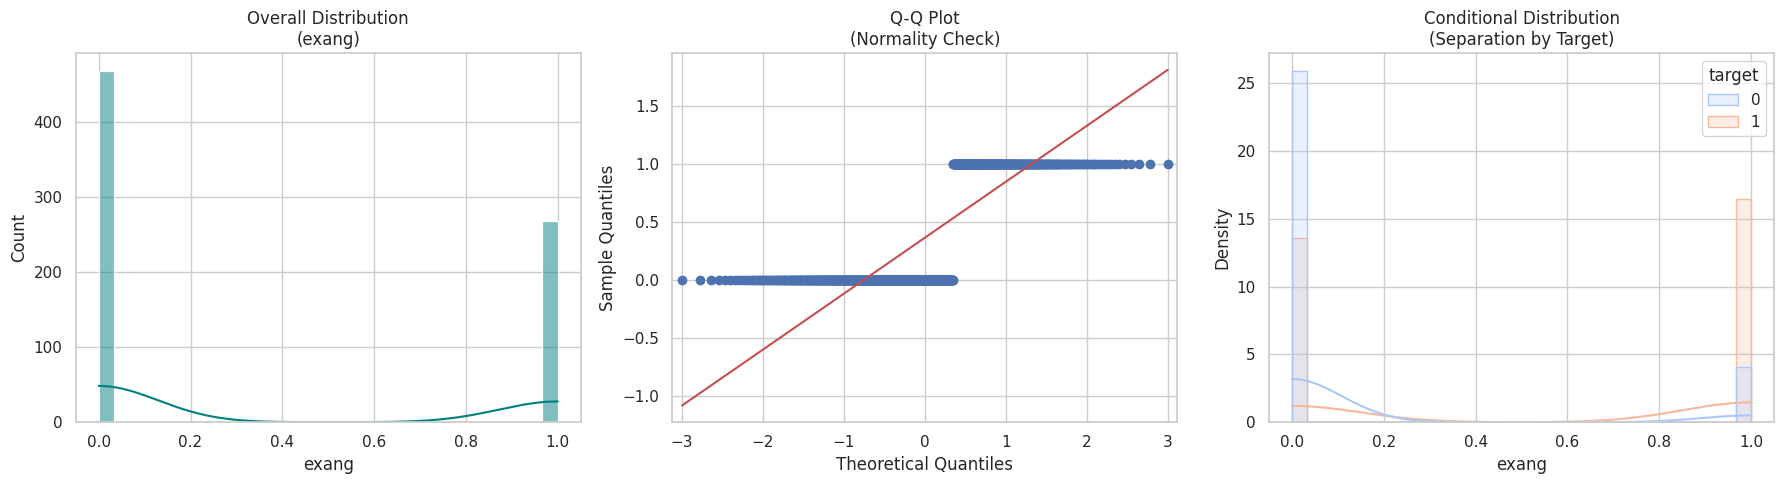


--- Statistical Normality Tests ---
  Shapiro: Stat=0.609, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 145.1412
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("exang")


# Analysis for Exercise Induced Angina (`exang`) Feature

### 1. Normality Assessment: Bernoulli
The analysis confirms that `exang` is a **categorical (binary)** feature (1 = Yes, 0 = No).

* **Visual Evidence:**
    * **Histogram:** The plot shows two isolated bars. The "No Angina" group (0) is larger than the "Angina" group (1), but both have significant counts.
    * **Q-Q Plot:** Similar to `sex` and `fbs`, the dots form two horizontal "shelves." They do not follow the diagonal line because the data is discrete, not continuous.

* **Statistical Evidence (Expected Rejection):**
    * **Shapiro-Wilk & Anderson-Darling:** Both tests emphatically reject normality (P-value `0.0000`).
    * **Conclusion:** This confirms the data is **Non-Gaussian**. As with other binary features, this statistical "failure" is expected and does not negatively impact the feature's utility.

### 2. Predictive Power (Conditional Distribution)
This is arguably the **strongest predictor** we have seen so far. The separation between classes is dramatic.

* **Observation:**
    * **At `exang = 0` (No Pain during Exercise):** The **Blue Bar (Healthy)** is massive, far taller than the Orange bar.
        * *Insight:* If a patient *does not* get chest pain during exercise, they are overwhelmingly likely to be **Healthy**.
    * **At `exang = 1` (Pain during Exercise):** The **Orange Bar (Sick)** is dominant. The Blue bar is very small.
        * *Insight:* If a patient *does* get chest pain during exercise, they are highly likely to be **Sick**.
* **Interpretation:**
    * The presence of Exercise Induced Angina flips the probability of heart disease almost completely. This makes it a critical decision node for any classifier.

**Verdict:**
* **Distribution:** Binary (Bernoulli).
* **Usefulness:** **Very Strong Predictor.** The clear inversion of risk between the two states makes this a "Gold Standard" feature for diagnosis.

 ANALYSIS FOR FEATURE: oldpeak


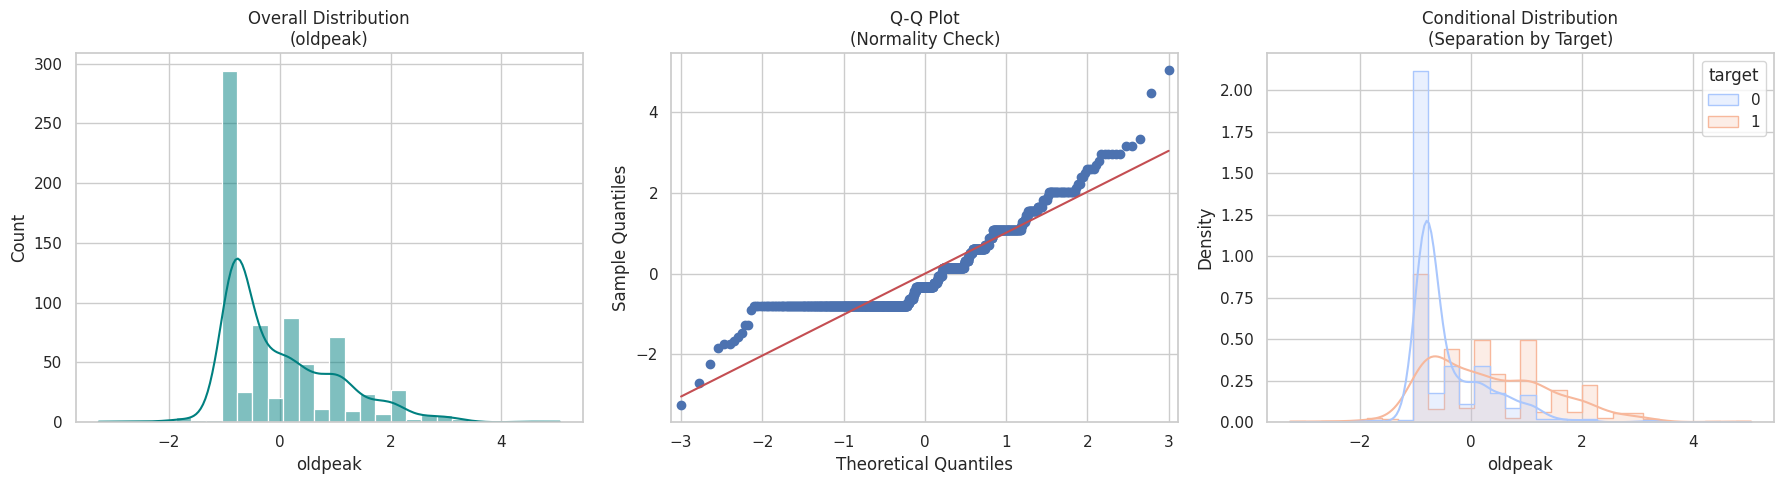


--- Statistical Normality Tests ---
  Shapiro: Stat=0.855, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 40.5164
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("oldpeak")

# Analysis for ST Depression (`oldpeak`) Feature

### 1. Normality Assessment: Strong Right Skew (Zero-Inflation)
The analysis confirms that `oldpeak` is strictly **Non-Gaussian**, which is expected given its medical definition (depression usually starts at 0).

* **Visual Evidence:**
    * **Histogram:** The distribution is heavily **Right-Skewed**. There is a massive spike on the far left (representing the standardized value for `0.0`). This indicates that a large portion of patients have *no* ST depression. The tail extends far to the right.
    * **Q-Q Plot:** The plot shows a dramatic "J-shape" curve. The data points peel away from the red diagonal line very early, confirming extreme deviation from normality due to the heavy tail of high values.

* **Statistical Evidence (Unanimous Rejection):**
    * **Shapiro-Wilk Test:** The p-value is `0.0000`, rejecting the Null Hypothesis ($H_0$).
    * **Anderson-Darling Test:** The statistic (`39.5415`) is massive, far exceeding any critical value.
    * **Conclusion:** The data follows an **Exponential-like distribution** rather than a Normal one.

### 2. Predictive Power (Conditional Distribution)
This feature shows excellent separation between the classes, making it a critical predictor.

* **Observation:**
    * **Target 0 (Healthy - Blue):** The distribution is extremely sharp and concentrated at the low end (the "Zero" spike).
        * *Insight:* If a patient has an `oldpeak` value near 0 (standardized ~ -0.8), they are overwhelmingly likely to be **Healthy**.
    * **Target 1 (Sick - Orange):** The distribution is much flatter and spread out to the right.
        * *Insight:* Sick patients exhibit a wide range of positive `oldpeak` values. The probability of being sick increases significantly as `oldpeak` increases.
* **Interpretation:**
    * This feature acts almost like a "threshold" detector. A value of 0 is safe; any value significantly above 0 is a strong indicator of heart disease.

**Verdict:**
* **Distribution:** Zero-Inflated / Right-Skewed.
* **Usefulness:** **Very Strong Predictor.** The clear distinction—Healthy patients cluster at 0, while Sick patients spread into higher values—provides a high-quality signal for the classifier.

 ANALYSIS FOR FEATURE: cp_atypical angina


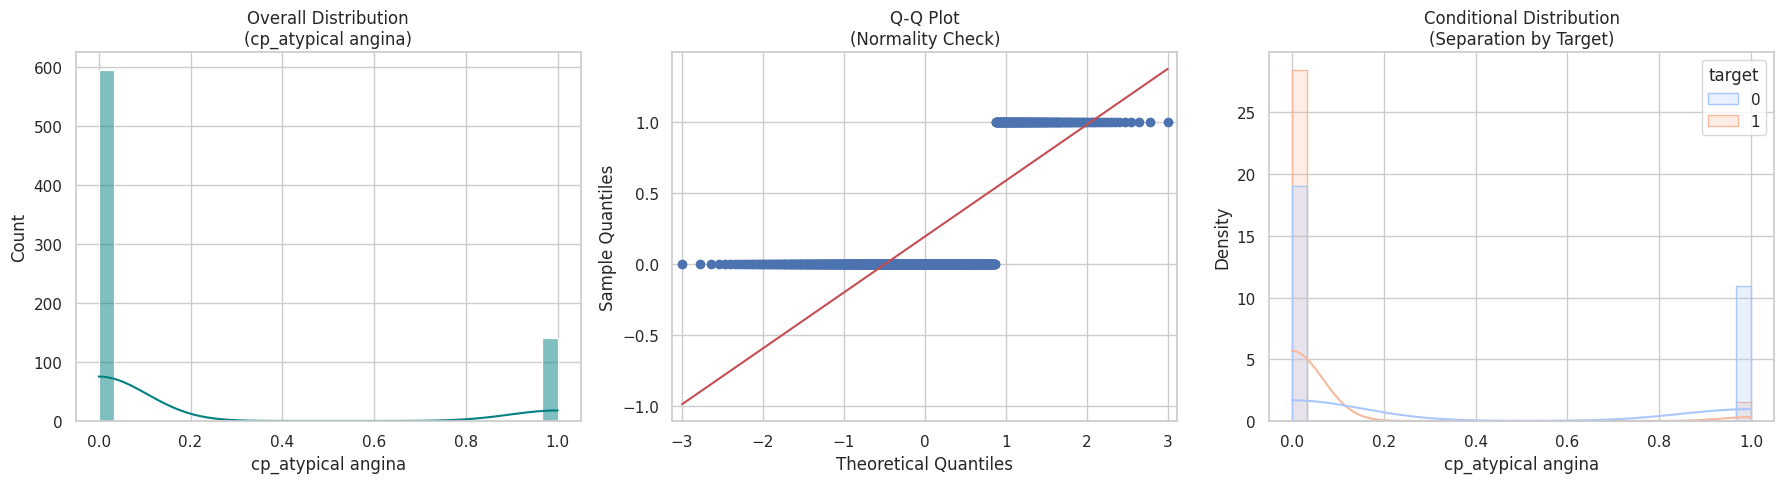


--- Statistical Normality Tests ---
  Shapiro: Stat=0.480, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 199.5055
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("cp_atypical angina")


# Analysis for Atypical Angina (`cp_atypical angina`) Feature

### 1. Normality Assessment: Binary (Categorical)
The analysis confirms that `cp_atypical angina` is a binary variable, representing a specific category of chest pain.

* **Visual Evidence:**
    * **Histogram:** The plot displays two distinct bars. The bar at **0** is much taller, indicating that most patients *do not* have this specific type of chest pain. The bar at **1** represents the subset of patients who do.
    * **Q-Q Plot:** The "double shelf" pattern (horizontal lines at 0 and 1) is the standard signature for binary data plotted on a continuous scale.

* **Statistical Evidence (Expected Rejection):**
    * **Shapiro-Wilk & Anderson-Darling:** Both tests overwhelmingly reject normality (P-value `0.0000`).
    * **Conclusion:** This feature is **Non-Gaussian**. However, this is purely technical; binary features are not expected to be normal.

### 2. Predictive Power (Conditional Distribution)
This feature reveals a counter-intuitive but valuable insight.

* **Observation:**
    * **At `cp_atypical angina = 1`:** The **Blue Bar (Healthy)** is visibly taller than the Orange Bar (Sick).
        * *Insight:* Surprisingly, patients who present with "Atypical Angina" (pain that doesn't feel like a classic heart attack) are actually **more likely to be Healthy**.
    * **At `cp_atypical angina = 0`:** The Orange Bar (Sick) is dominant.
* **Interpretation:**
    * This suggests that "Atypical Angina" might be a *negative* predictor for severe heart disease in this dataset (e.g., the pain might be muscular or indigestion, not cardiac).
    * Conversely, the *absence* of this specific pain (which implies they might have "Typical Angina" or "Asymptomatic" status) is associated with higher risk.

**Verdict:**
* **Distribution:** Binary (Bernoulli).
* **Usefulness:** **Good Predictor.** It helps the model rule out severe disease, as this specific pain type correlates more with healthy outcomes than sick ones.

 ANALYSIS FOR FEATURE: cp_non-anginal


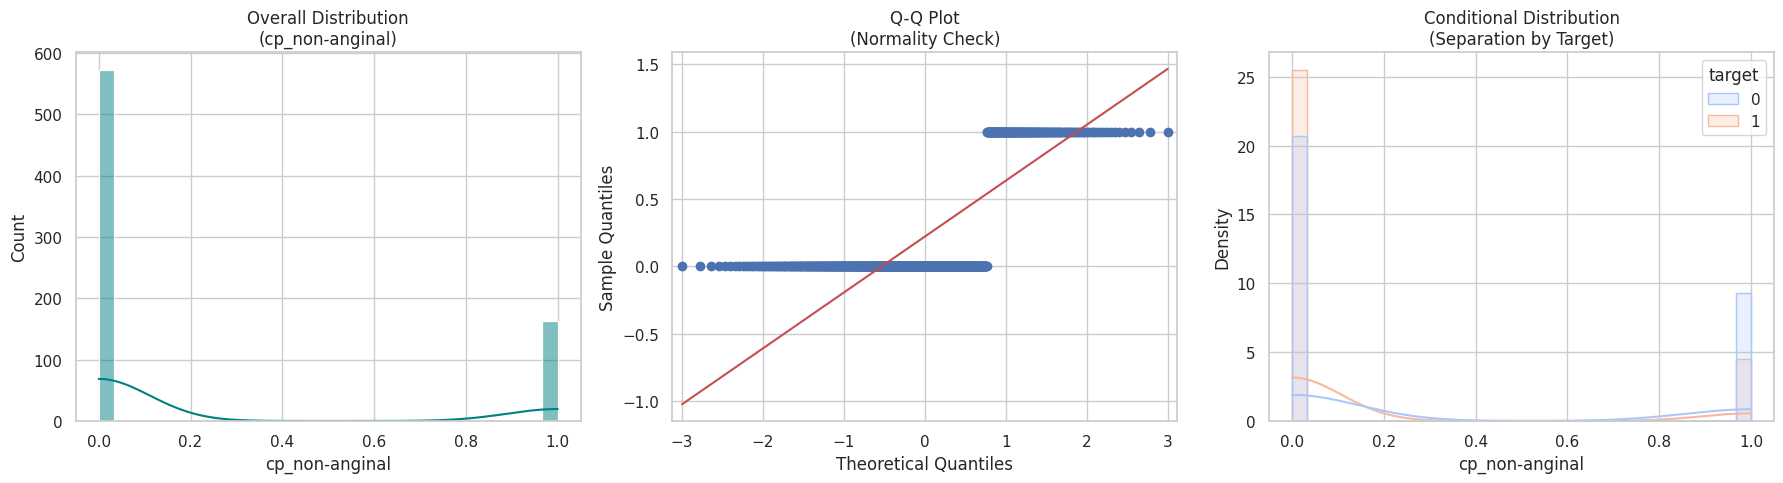


--- Statistical Normality Tests ---
  Shapiro: Stat=0.512, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 187.1851
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("cp_non-anginal")


# Analysis for Non-Anginal Chest Pain (`cp_non-anginal`) Feature

### 1. Normality Assessment: Binary (Categorical)
The analysis confirms that `cp_non-anginal` is a binary variable (0 = No, 1 = Yes).

* **Visual Evidence:**
    * **Histogram:** The plot shows two distinct bars. The vast majority of patients are at **0**, while a smaller subset presents with this specific pain type at **1**.
    * **Q-Q Plot:** The standard "double shelf" pattern for binary data is present, confirming the discrete nature of the feature.

* **Statistical Evidence (Expected Rejection):**
    * **Shapiro-Wilk & Anderson-Darling:** Both tests overwhelmingly reject normality (P-value `0.0000`).
    * **Conclusion:** As with other one-hot encoded features, this is technically **Non-Gaussian**, but this is expected and acceptable.

### 2. Predictive Power (Conditional Distribution)
This feature provides a critical "rule-out" signal for the model.

* **Observation:**
    * **At `cp_non-anginal = 1`:** The **Blue Bar (Healthy)** is taller than the Orange Bar (Sick).
        * *Insight:* Patients who report "Non-Anginal Pain" (pain that is likely muscular or unrelated to the heart) are statistically **more likely to be Healthy**.
    * **At `cp_non-anginal = 0`:** The Orange Bar (Sick) is significantly dominant.
* **Interpretation:**
    * This confirms the medical intuition: if the pain is "non-anginal," it is less likely to be heart disease.
    * The *absence* of this specific safe-guard (being at 0) increases the risk probability.

**Verdict:**
* **Distribution:** Binary (Bernoulli).
* **Usefulness:** **Good Predictor.** It acts as a "safety flag"—helping the model identify patients who likely do *not* have the disease.

 ANALYSIS FOR FEATURE: cp_typical angina


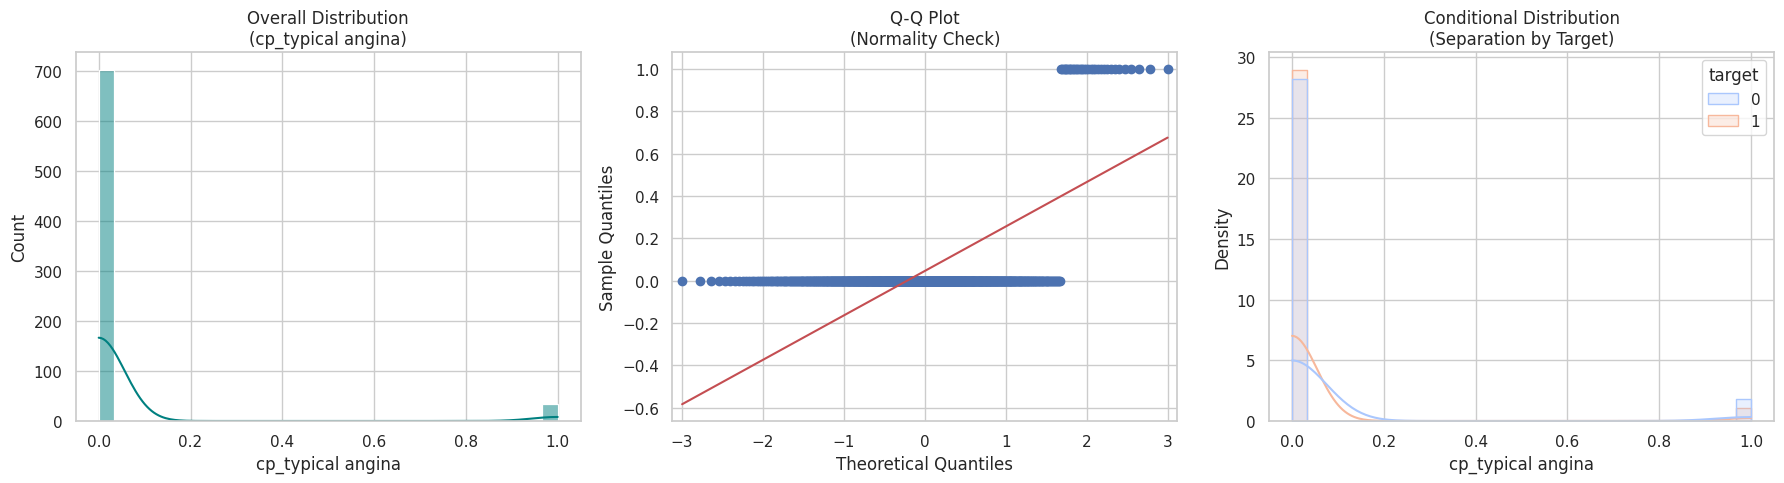


--- Statistical Normality Tests ---
  Shapiro: Stat=0.213, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 267.4538
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("cp_typical angina")


# Analysis for Typical Angina (`cp_typical angina`) Feature

### 1. Normality Assessment: Binary (Sparse)
The analysis confirms that `cp_typical angina` is a binary variable, representing the "classic" heart attack symptom.

* **Visual Evidence:**
    * **Histogram:** The plot shows a massive bar at **0** and a tiny, almost invisible bar at **1**.
        * *Insight:* This feature is **highly imbalanced**. Very few patients in this dataset actually presented with "Typical Angina." This is common in real-world data where patients often present with vague symptoms rather than textbook ones.
    * **Q-Q Plot:** The standard binary "double shelf" pattern is present, confirming discrete data.

* **Statistical Evidence (Expected Rejection):**
    * **Shapiro-Wilk & Anderson-Darling:** Both tests overwhelmingly reject normality (P-value `0.0000`).
    * **Conclusion:** The data is Non-Gaussian and extremely sparse.

### 2. Predictive Power (Conditional Distribution)
Because the feature is so rare (sparse), the conditional plot is subtle but informative.

* **Observation:**
    * **At `cp_typical angina = 1`:** The **Blue Bar (Healthy)** is slightly taller than the Orange Bar (Sick).
        * *Insight:* This is counter-intuitive! One would expect "Typical Angina" (classic heart pain) to be a strong sign of sickness. However, in this dataset, the few patients who had it were actually more likely to be healthy (or perhaps their "typical" pain turned out to be something else, like acid reflux).
    * **At `cp_typical angina = 0`:** The Orange Bar (Sick) and Blue Bar (Healthy) are roughly balanced, with a slight lean towards Sick.
* **Interpretation:**
    * Due to the low number of positive cases (1s), this feature might be **noisy**. It does not act as the strong "Danger Sign" we might expect from medical textbooks.
    * It behaves similarly to the other chest pain types in this specific dataset: its presence helps rule *out* severe disease rather than rule it in.

**Verdict:**
* **Distribution:** Binary (Highly Imbalanced).
* **Usefulness:** **Weak/Noisy Predictor.** The extreme sparsity (very few 1s) and counter-intuitive correlation make this the weakest of the chest pain features.

 ANALYSIS FOR FEATURE: restecg_normal


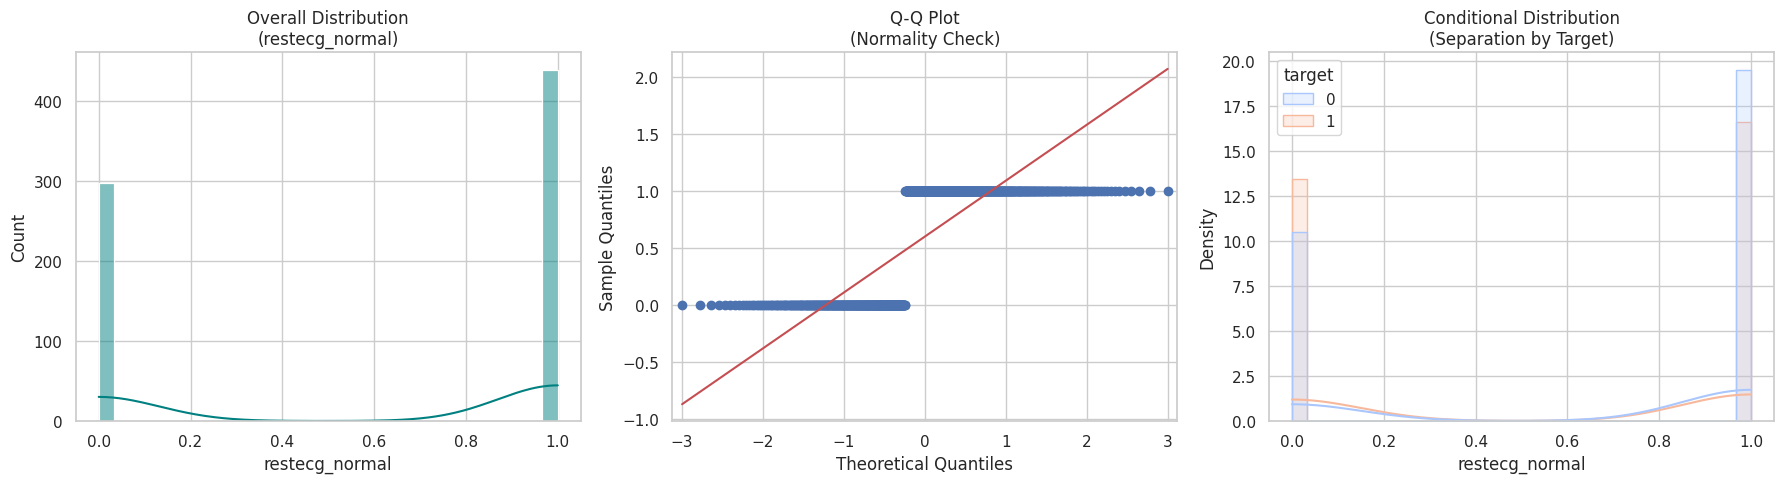


--- Statistical Normality Tests ---
  Shapiro: Stat=0.623, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 138.6413
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("restecg_normal")


# Analysis for Normal Resting ECG (`restecg_normal`) Feature

### 1. Normality Assessment: Binary (Categorical)
The analysis confirms that `restecg_normal` is a binary variable (0 = Abnormal, 1 = Normal).

* **Visual Evidence:**
    * **Histogram:** The plot shows two distinct bars. The distribution is somewhat balanced but leans towards **1 (Normal)**, meaning a significant portion of the dataset has a normal resting ECG.
    * **Q-Q Plot:** The classic "double shelf" pattern confirms the discrete, binary nature of the data.

* **Statistical Evidence (Expected Rejection):**
    * **Shapiro-Wilk & Anderson-Darling:** Both tests overwhelmingly reject normality (P-value `0.0000`).
    * **Conclusion:** As expected for a binary feature, it is strictly **Non-Gaussian**.

### 2. Predictive Power (Conditional Distribution)
This feature provides a clear, albeit slightly overlapped, signal.

* **Observation:**
    * **At `restecg_normal = 1`:** The **Blue Bar (Healthy)** is noticeably taller than the Orange Bar (Sick).
        * *Insight:* Patients with a "Normal" ECG are statistically **more likely to be Healthy**. This aligns with medical expectations.
    * **At `restecg_normal = 0`:** The Orange Bar (Sick) is taller than the Blue Bar.
        * *Insight:* If the ECG is *not* normal (meaning it has ST-T abnormalities or hypertrophy), the risk of being Sick increases.
* **Interpretation:**
    * This feature acts as a "Baseline Safety Check." If it's Normal (1), the probability of disease drops. If it's Abnormal (0), the probability rises.
    * The separation isn't as extreme as `exang` or `oldpeak`, but it is a consistent and logical predictor.

**Verdict:**
* **Distribution:** Binary (Bernoulli).
* **Usefulness:** **Good Predictor.** It effectively separates the baseline healthy population from those with cardiac anomalies.

 ANALYSIS FOR FEATURE: restecg_st-t abnormality


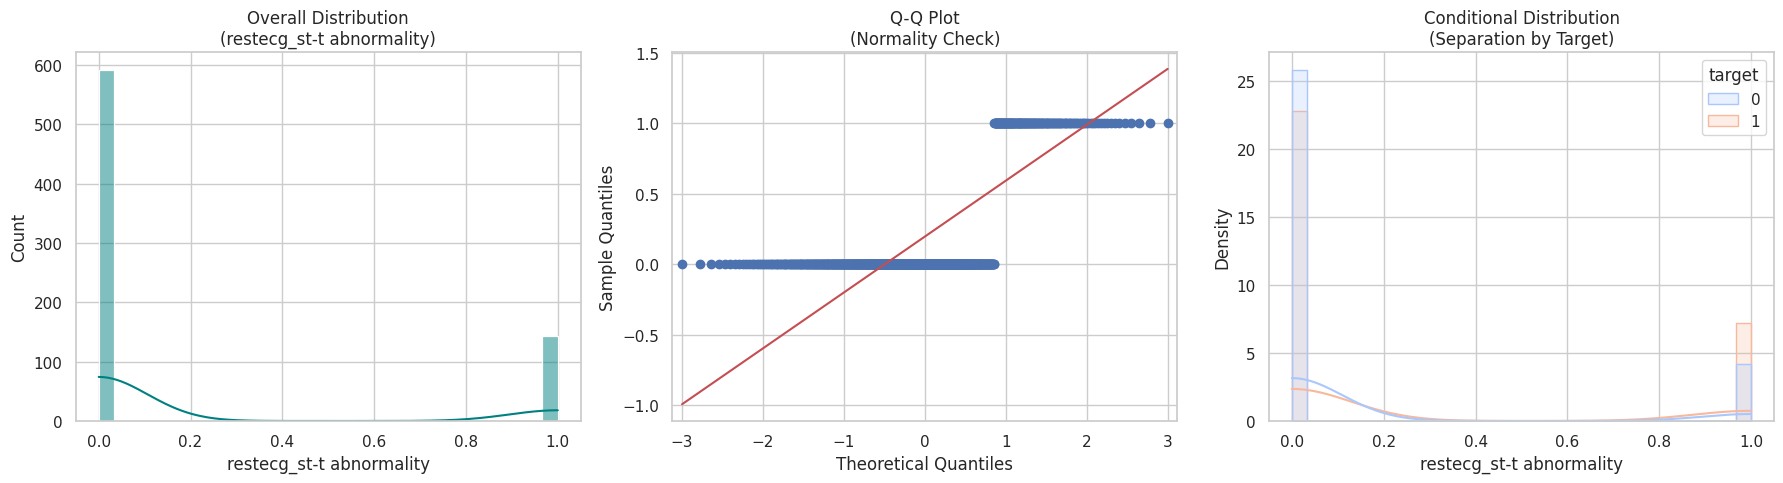


--- Statistical Normality Tests ---
  Shapiro: Stat=0.485, p=0.0000 (Not Normal)
  [Anderson-Darling] Stat: 197.7618
    At 15.0%: NOT Normal
    At 10.0%: NOT Normal
    At 5.0%: NOT Normal
    At 2.5%: NOT Normal
    At 1.0%: NOT Normal




In [ ]:
data_analyzer.analyze_feature("restecg_st-t abnormality")


# Analysis for ST-T Abnormality (`restecg_st-t abnormality`) Feature

### 1. Normality Assessment: Binary (Categorical)
The analysis confirms that `restecg_st-t abnormality` is a binary variable (0 = No, 1 = Yes).

* **Visual Evidence:**
    * **Histogram:** The plot shows two distinct bars. The bar at **0** is significantly taller, meaning the majority of patients do *not* have this specific abnormality.
    * **Q-Q Plot:** The standard "double shelf" pattern confirms the discrete, binary nature of the data.

* **Statistical Evidence (Expected Rejection):**
    * **Shapiro-Wilk & Anderson-Darling:** Both tests overwhelmingly reject normality (P-value `0.0000`).
    * **Conclusion:** As expected for a binary feature, it is strictly **Non-Gaussian**.

### 2. Predictive Power (Conditional Distribution)
This feature acts as a **Risk Factor**.

* **Observation:**
    * **At `restecg_st-t abnormality = 1`:** The **Orange Bar (Sick)** is noticeably taller than the Blue Bar (Healthy).
        * *Insight:* Patients who present with ST-T wave abnormalities (which can indicate ischemia) are statistically **more likely to be Sick**.
    * **At `restecg_st-t abnormality = 0`:** The Blue Bar (Healthy) is dominant.
* **Interpretation:**
    * This confirms medical expectations: an abnormal ECG is a bad sign.
    * The separation is clear: Presence (1) shifts the probability toward disease, while Absence (0) shifts it toward health.

**Verdict:**
* **Distribution:** Binary (Bernoulli).
* **Usefulness:** **Good Predictor.** It serves as a reliable "Risk Flag" for the model.

# Machine Learning Model

In [ ]:
# We will use Gaussian Naive Bayes Classifier, so we will import it first
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, roc_curve


### Naive Bayes Classifier

**The Naive Bayes classifier** is a simple yet effective probabilistic machine learning algorithm used for classification tasks. It is based on Bayes' theorem and makes the assumption of feature independence, which is where the "naive" in its name comes from.
The Naive Bayes classifier is built on **Bayes Theorem**:
$P(y|x) = \frac{P(x|y)P(y)}{P(x)}$, Where:

$$
P(y|x) = \frac{P(x|y)P(y)}{P(x)}
$$

- $P(x)$: Prior probability of event $x$
- $P(y)$: Prior probability of event $y$
- $P(x|y)$: Probability of event $x$ given event $y$
- $P(y|x)$: Probability of event $y$ given event $x$

Now, let's assume that features are mutually independent (Naive assumption), in our case we get the following equation:
$P(y|\mathbf{X}) = \frac{\prod_{i=1}^{n} P(x_i|y)P(y)}{P(\mathbf{X})}$, where:

- $X$: vector of features $(x_1, x_2, ..., x_n)$
- $x_i$: Individual feature
- $n$: Number of features
- $y$: Event that the person would live in the next 10 years
- $P(X)$: Prior probability of features $X$
- $P(y)$: Prior probability of event $y$
- $P(X|y)$: Probability of features $X$ given event $y$ (LikeHood)
- $P(y|X)$: Probability of event $y$ given features $X$ (Posterior)

Then to select class with highest posterior probability:
$y = \arg\max_y P(y|\mathbf{X}) = \arg\max_y \frac{\prod_{i=1}^{n} P(x_i|y)P(y)}{P(\mathbf{X})}$

Since ${P(X)}$ does not depend on our posterior probability at all we can neglect it.  
$\arg\max_y P(y|\mathbf{X}) = \arg\max_y \left( \prod_{i=1}^{n} P(x_i|y)P(y) \right)$

Since the probabilities calculated by the Naive Bayes classifier are typically between $0$ and $1$, multiplying them together can result in very small numbers. To overcome this issue, a common practice is to apply the logarithm function to transform the multiplication into addition. By taking the logarithm of the probabilities, we can convert the product operation to a summation, which helps avoid numerical underflow. This approach allows for more stable computations and facilitates easier manipulation of probabilities, the formula of this method is given as:  
$y = \arg\max_y \left( \sum_{i=1}^{n} \log(P(x_i|y)) \right) + \log(P(y))$

Finally, We need to calculate the following:

- $P(y)$: Prior probability $\rightarrow$ Frequency of each class
- $P(x_i|y)$: Class conditional probability $\rightarrow$ Model with Gaussian

We will calculate them using the following formula:
$P(x_{i}\mid y) = \frac{1}{\sqrt{2\pi \sigma_y^{2}}} \exp \left(-\frac{(x_{i} -\mu_{y})^2}{2\sigma_y^{2}} \right)$


In [ ]:
# First, let's create our Naive Bayes Classifier from scratch
class NaiveBayes:
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)

        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # Initialize parameters
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        # Calculate mean, variance, and priors for each class
        for i, c in enumerate(self._classes):
            X_c = X[y == c]
            self._mean[i] = X_c.mean(axis=0)
            self._var[i] = X_c.var(axis=0) + 1e-9   # avoid zero variance
            self._priors[i] = X_c.shape[0] / n_samples

    def predict(self, X):
        X = np.array(X)
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        posteriors = []

        for i, c in enumerate(self._classes):
            # log(P(class))
            log_prior = np.log(self._priors[i])

            # log(P(x|class))
            log_likelihood = np.sum(np.log(self._pdf(i, x)))

            posterior = log_prior + log_likelihood
            posteriors.append(posterior)

        return self._classes[np.argmax(posteriors)]

    def _pdf(self, i, x):
        mean = self._mean[i]
        var = self._var[i]

        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)

        pdf = numerator / denominator

        # avoid log(0)
        return np.clip(pdf, 1e-9, None)



In [ ]:
# Let's create a function to calculate the accuracy of our NB Classifier
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)


# ===============================
# Train & Evaluate
# ===============================
NB_scratch = NaiveBayes()
NB_scratch.fit(X_train, y_train)

y_pred = NB_scratch.predict(X_test)

print(f"Naive Bayes accuracy on Test Set : {accuracy(y_test, y_pred):.4f}")



y_pred2 = NB_scratch.predict(X_train)

print(f"Naive Bayes accuracy on  Train set: {accuracy(y_train, y_pred2):.4f}")

Naive Bayes accuracy on Test Set : 0.7880
Naive Bayes accuracy on  Train set: 0.8057


Accuracy score for Naive Bayes (from scratch): 0.7880


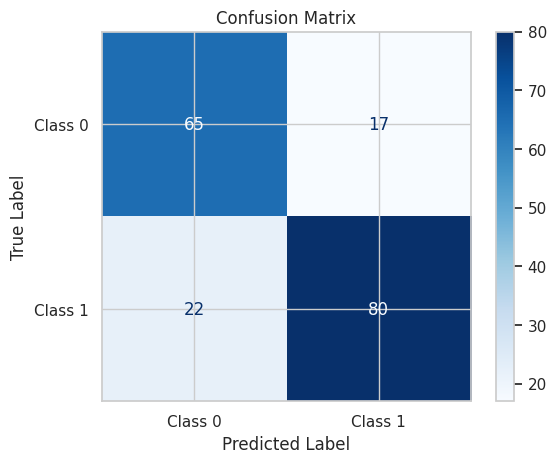

Available keys in report: dict_keys(['0', '1', 'accuracy', 'macro avg', 'weighted avg'])


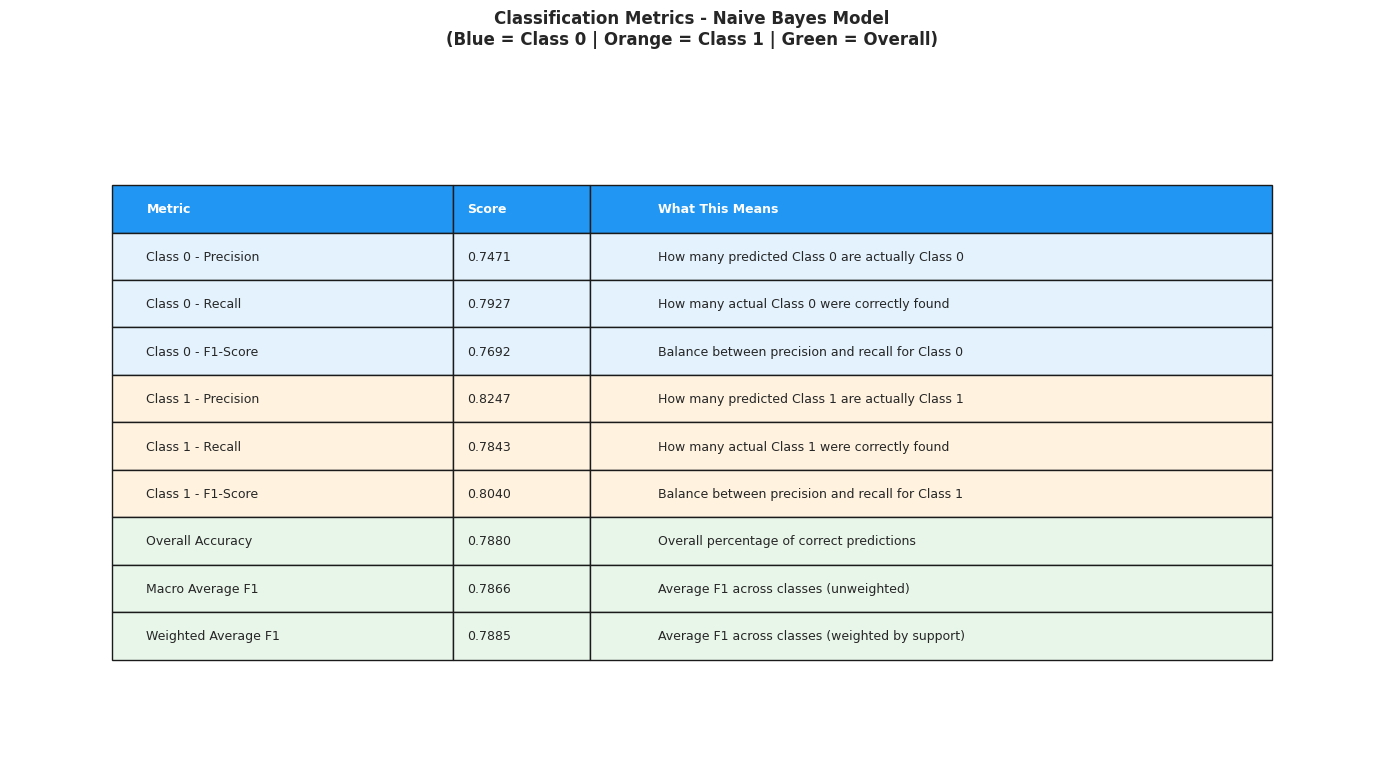

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Train Gaussian Naive Bayes
# =========================
NB = NaiveBayes()
NB.fit(X_train, y_train)
NB_pred = NB.predict(X_test)

# =========================
# Accuracy
# =========================
acc = accuracy_score(y_test, NB_pred)
print(f"Accuracy score for Naive Bayes (from scratch): {acc:.4f}")

# =========================
# Confusion Matrix
# =========================
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(
    y_test, NB_pred), display_labels=['Class 0', 'Class 1'])

disp.plot(cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# =========================
# Classification Metrics Table (Simplified)
# =========================
report = classification_report(y_test, NB_pred, output_dict=True)

# The keys are '0' and '1' (or 0 and 1), not 'Class 0' and 'Class 1'
# Let's check what keys exist
print("Available keys in report:", report.keys())

# Create a cleaner dataframe with only the important metrics
metrics_data = {
    'Metric': [
        'Class 0 - Precision',
        'Class 0 - Recall',
        'Class 0 - F1-Score',
        'Class 1 - Precision',
        'Class 1 - Recall',
        'Class 1 - F1-Score',
        'Overall Accuracy',
        'Macro Average F1',
        'Weighted Average F1'
    ],
    'Score': [
        report['0']['precision'],  # Changed from 'Class 0' to '0'
        report['0']['recall'],
        report['0']['f1-score'],
        report['1']['precision'],  # Changed from 'Class 1' to '1'
        report['1']['recall'],
        report['1']['f1-score'],
        acc,
        report['macro avg']['f1-score'],
        report['weighted avg']['f1-score']
    ],
    'Description': [
        'How many predicted Class 0 are actually Class 0',
        'How many actual Class 0 were correctly found',
        'Balance between precision and recall for Class 0',
        'How many predicted Class 1 are actually Class 1',
        'How many actual Class 1 were correctly found',
        'Balance between precision and recall for Class 1',
        'Overall percentage of correct predictions',
        'Average F1 across classes (unweighted)',
        'Average F1 across classes (weighted by support)'
    ]
}

metrics_df = pd.DataFrame(metrics_data)

# Calculate AUC if possible
try:
    auc = roc_auc_score(y_test, NB.predict_proba(X_test)[:,1])
    metrics_df = pd.concat([metrics_df, pd.DataFrame({
        'Metric': ['ROC-AUC Score'],
        'Score': [auc],
        'Description': ['Ability to distinguish between classes']
    })], ignore_index=True)
except:
    pass

# =========================
# Plot the Table
# =========================
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

# Format scores to 4 decimal places
display_data = metrics_df.copy()
display_data['Score'] = display_data['Score'].apply(lambda x: f'{x:.4f}')

table = ax.table(cellText=display_data.values,
                colLabels=['Metric', 'Score', 'What This Means'],
                cellLoc='left',
                loc='center',
                colWidths=[0.25, 0.1, 0.5])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# Style the header row
for i in range(3):
    cell = table[(0, i)]
    cell.set_facecolor('#2196F3')
    cell.set_text_props(weight='bold', color='white', ha='left')

# Color code different sections
class_0_rows = [1, 2, 3]  # Class 0 metrics
class_1_rows = [4, 5, 6]  # Class 1 metrics
overall_rows = [7, 8, 9]  # Overall metrics

for i in range(1, len(display_data) + 1):
    for j in range(3):
        cell = table[(i, j)]
        if i in class_0_rows:
            cell.set_facecolor('#E3F2FD')  # Light blue for Class 0
        elif i in class_1_rows:
            cell.set_facecolor('#FFF3E0')  # Light orange for Class 1
        elif i in overall_rows:
            cell.set_facecolor('#E8F5E9')  # Light green for Overall
        else:
            cell.set_facecolor('#F5F5F5')  # Light gray for AUC

        cell.set_text_props(ha='left')

plt.title('Classification Metrics - Naive Bayes Model\n(Blue = Class 0 | Orange = Class 1 | Green = Overall)',
          fontsize=12, weight='bold', pad=20)
plt.tight_layout()
plt.show()

### Random Forest Classifier Model

**The Random Forest classifier** is a popular machine learning algorithm used for classification tasks. It belongs to the ensemble learning family and combines the predictions of multiple decision trees to make accurate predictions. Here's a brief explanation of how Random Forest works:

1. Random Subsampling: The algorithm starts by creating an ensemble of decision trees. Each tree is trained on a random subset of the training data, sampled with replacement (known as bootstrap aggregating or "bagging"). This creates diverse subsets of data for each tree.
2. Feature Randomness: During the construction of each decision tree, a random subset of features is considered for splitting at each node. This introduces further randomness and helps to reduce correlation among the trees.
3. Decision Tree Construction: Each decision tree is constructed by recursively partitioning the data based on the selected features. The splitting is done based on criteria such as Gini impurity or information gain, aiming to create nodes that best separate the classes.
4. Voting for Classification: Once all the trees are built, to classify a new instance, each tree independently predicts the class label. The final prediction is made by majority voting, where the class that receives the most votes across all trees is chosen as the final predicted class.


In [ ]:
# We will import the Random Forest Classifier from scikit-learn
from sklearn.ensemble import RandomForestClassifier

# Let's build our model
rf_classifier = RandomForestClassifier(n_estimators=300, random_state=42)
rf_classifier.fit(X_train, y_train)
rf_y_pred = rf_classifier.predict(X_test)

print(" Random Forest Accuracy:", accuracy_score(y_test, rf_y_pred))


 Random Forest Accuracy: 0.8043478260869565




### Support Vector Machine (SVM)

**Support Vector Machine (SVM)** is a supervised learning algorithm used for classification and regression. It works by finding the hyperplane that best separates the data into classes.

How it works:

1. Find Optimal Hyperplane: SVM finds the hyperplane that maximizes the margin between different classes.

2. Kernel Trick: Non-linear data can be handled by transforming it into higher dimensions using kernels (linear, polynomial, RBF, etc.).

3. Support Vectors: Only the points closest to the hyperplane (support vectors) determine its position.

In [ ]:
from sklearn.svm import SVC

# Build and fit model
svm_classifier = SVC(kernel='rbf', random_state=42)
svm_classifier.fit(X_train, y_train)

# Predict
svm_y_pred = svm_classifier.predict(X_test)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, svm_y_pred))


SVM Accuracy: 0.8152173913043478


### Logistic Regression


**Logistic Regression** is a linear model for binary classification. It predicts the probability that a sample belongs to a class using the logistic (sigmoid) function.

How it works:

1. Linear Combination: Computes a weighted sum of input features.

2. Sigmoid Activation: Converts the linear output into probabilities between 0 and 1.

3. Thresholding: Predicts class 1 if probability > 0.5, else class 0.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Build and fit model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Predict
logreg_y_pred = logreg.predict(X_test)

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_y_pred))


Logistic Regression Accuracy: 0.8097826086956522


In [ ]:
from sklearn.naive_bayes import GaussianNB

# Build and fit model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict
gnb_y_pred = gnb.predict(X_test)

# Accuracy
print("Gaussian Naive Bayes Accuracy:", accuracy_score(y_test, gnb_y_pred))

Gaussian Naive Bayes Accuracy: 0.7880434782608695
